In [1]:
# Understanding the Dataset

import pandas as pd

df = pd.read_csv("../data/AAPL_engineered.csv")

print(df.head())
print(df.columns)
print(df.info())
print(df.describe())


         date       open       high        low      close     volume  \
0  2016-05-13  20.526531  20.907412  20.526531  20.645128  177571200   
1  2016-05-16  21.071627  21.527773  20.902854  21.411455  245039200   
2  2016-05-17  21.564266  21.598476  21.213034  21.322508  187667600   
3  2016-05-18  21.475312  21.714787  21.413732  21.566540  168249600   
4  2016-05-19  21.584794  21.584794  21.340757  21.484442  121768400   

       rsi_7     rsi_14       cci_7      cci_14     sma_50     ema_50  \
0  18.165817  23.979977 -121.638643 -110.854532  23.417778  22.794850   
1  47.605299  38.529057   70.931992    1.472171  23.378976  22.740599   
2  45.393943  37.628871   83.412084   57.388288  23.343563  22.684988   
3  52.462071  41.656372  110.755574  136.677076  23.316839  22.641127   
4  49.925657  40.704101   69.665180   84.663171  23.288065  22.595767   

     sma_100    ema_100      macd  bollinger  TrueRange     atr_7    atr_14  \
0  22.886907  23.079897 -0.857738  24.981912   0.

In [2]:
print(f"Dataset Shape: {df.shape}\n")

print("Missing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (2415, 20)

Missing Values:
date              0
open              0
high              0
low               0
close             0
volume            0
rsi_7             0
rsi_14            0
cci_7             0
cci_14            0
sma_50            0
ema_50            0
sma_100           0
ema_100           0
macd              0
bollinger         0
TrueRange         0
atr_7             0
atr_14            0
next_day_close    0
dtype: int64

Data Types:
date                  str
open              float64
high              float64
low               float64
close             float64
volume              int64
rsi_7             float64
rsi_14            float64
cci_7             float64
cci_14            float64
sma_50            float64
ema_50            float64
sma_100           float64
ema_100           float64
macd              float64
bollinger         float64
TrueRange         float64
atr_7             float64
atr_14            float64
next_day_close    float64
dtype: obje

In [3]:
print(df["date"].head())
print(df["date"].tail())


0    2016-05-13
1    2016-05-16
2    2016-05-17
3    2016-05-18
4    2016-05-19
Name: date, dtype: str
2410    2025-12-12
2411    2025-12-15
2412    2025-12-16
2413    2025-12-17
2414    2025-12-18
Name: date, dtype: str


In [4]:
df["date"] = pd.to_datetime(df["date"])

print(df.dtypes)

date              datetime64[us]
open                     float64
high                     float64
low                      float64
close                    float64
volume                     int64
rsi_7                    float64
rsi_14                   float64
cci_7                    float64
cci_14                   float64
sma_50                   float64
ema_50                   float64
sma_100                  float64
ema_100                  float64
macd                     float64
bollinger                float64
TrueRange                float64
atr_7                    float64
atr_14                   float64
next_day_close           float64
dtype: object


In [5]:
# Correlation Analysis: How strongly is each features related to tomorrow's closing price?

print(df.corr()["next_day_close"].sort_values(ascending=False))

next_day_close    1.000000
close             0.999449
high              0.999298
low               0.999297
open              0.999090
bollinger         0.995534
ema_50            0.994214
sma_50            0.992227
ema_100           0.990094
sma_100           0.985492
date              0.968995
atr_14            0.845578
atr_7             0.813459
TrueRange         0.641960
macd              0.226489
cci_7            -0.032718
cci_14           -0.040329
rsi_7            -0.058506
rsi_14           -0.065464
volume           -0.537128
Name: next_day_close, dtype: float64


In [6]:
# Features and Targets creation

X = df.drop(columns=["next_day_close", "date"])
y = df["next_day_close"]

print(X.head())
print(y.head())

        open       high        low      close     volume      rsi_7  \
0  20.526531  20.907412  20.526531  20.645128  177571200  18.165817   
1  21.071627  21.527773  20.902854  21.411455  245039200  47.605299   
2  21.564266  21.598476  21.213034  21.322508  187667600  45.393943   
3  21.475312  21.714787  21.413732  21.566540  168249600  52.462071   
4  21.584794  21.584794  21.340757  21.484442  121768400  49.925657   

      rsi_14       cci_7      cci_14     sma_50     ema_50    sma_100  \
0  23.979977 -121.638643 -110.854532  23.417778  22.794850  22.886907   
1  38.529057   70.931992    1.472171  23.378976  22.740599  22.859025   
2  37.628871   83.412084   57.388288  23.343563  22.684988  22.830480   
3  41.656372  110.755574  136.677076  23.316839  22.641127  22.801264   
4  40.704101   69.665180   84.663171  23.288065  22.595767  22.772534   

     ema_100      macd  bollinger  TrueRange     atr_7    atr_14  
0  23.079897 -0.857738  24.981912   0.380881  0.458302  0.473165  


###### *The feature matrix consisted of 18 predictor variables, including historical OHLCV data and engineered technical indicators (RSI, CCI, SMA, EMA, MACD, Bollinger Band, True Range, and ATR). The target variable was the next-day closing price (next_day_close). The date column was excluded because it served only as a temporal index and was not treated as a predictive feature.*

In [7]:
# Creating a Random Train/Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)



(1932, 18)
(483, 18)
(1932,)
(483,)


##### At this point we have 1932 training rows, 483 testing rows and 18 input features for both. We have 1932 correct target values for training and 483 correct target values for testing. Our data is now ready for the first model.

## **Linear Regression - Random Split**

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print(predictions[:5])
print(y_test.head())

[ 37.70195502  31.98917166 135.13277456 194.60541067  84.77697038]
410      39.632290
199      32.359241
1670    123.211189
1934    193.353989
1036     85.757645
Name: next_day_close, dtype: float64


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr_random = mean_absolute_error(y_test, predictions)
mse_lr_random = mean_squared_error(y_test, predictions)
rmse_lr_random = mse_lr_random ** 0.5
r2_lr_random = r2_score(y_test, predictions)

print("MAE: ", mae_lr_random)
print("MSE: ", mse_lr_random)
print("RMSE: ", rmse_lr_random)
print("R2: ", r2_lr_random)



MAE:  3.270253945552896
MSE:  19.798572185368972
RMSE:  4.4495586506269325
R2:  0.9962468116009711


##### *In random train-test splitting, observations from different time periods are mixed together. As a result, the model may be trained on data from later years while being tested on earlier years, which does not reflect how financial forecasting works in practice. Since stock prices and market conditions are highly dependent on time, the model gains indirect knowledge of patterns across the entire decade. This can lead to overly optimistic performance estimates because the model is evaluated in an environment where information from future periods influences the learning process, making the prediction task easier than it would be in a real-world forecasting scenario.*

## **Linear Regression - Chronological**

In [10]:
# Inspecting the date range

print(df["date"].min())
print(df["date"].max())

# finding the 80% cutoff point now

split_index = int(len(df)*0.8)

print(split_index)
print(df.iloc[split_index]["date"])


2016-05-13 00:00:00
2025-12-18 00:00:00
1932
2024-01-18 00:00:00


In [11]:
# creating new training and testing data using chronological order

X_train_time = X.iloc[:split_index]
X_test_time = X.iloc[split_index:]

y_train_time = y.iloc[:split_index]
y_test_time = y.iloc[split_index:]

print(X_train_time.shape)
print(X_test_time.shape)
print(y_train_time.shape)
print(y_test_time.shape)



(1932, 18)
(483, 18)
(1932,)
(483,)


In [12]:
from sklearn.linear_model import LinearRegression

time_model = LinearRegression()

time_model.fit(X_train_time, y_train_time)

time_predictions = time_model.predict(X_test_time)

print(time_predictions[:5])
print(y_test_time.head())


[189.52609655 191.94941616 193.73269312 193.66132844 193.17360589]
1932    189.767853
1933    192.076035
1934    193.353989
1935    192.680344
1936    192.353424
Name: next_day_close, dtype: float64


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_lr_time = mean_absolute_error(y_test_time, time_predictions)
mse_lr_time = mean_squared_error(y_test_time, time_predictions)
rmse_lr_time = mse_lr_time ** 0.5
r2_lr_time = r2_score(y_test_time, time_predictions)

print("MAE:", mae_lr_time)
print("MSE:", mse_lr_time)
print("RMSE:", rmse_lr_time)
print("R2:", r2_lr_time)

MAE: 5.71508908481005
MSE: 53.750128714901486
RMSE: 7.3314479275857565
R2: 0.9333656435425824


###### Linear Regression achieved stronger performance under random train-test splitting (MAE = 3.270253945552896, RMSE = 4.4495586506269325, R² = 0.9962468116009711) than under chronological time-based validation (MAE = 5.71508908481005, RMSE = 7.3314479275857565, R² = 0.9333656435425824). The increase in prediction error suggests that random splitting may provide overly optimistic estimates of model performance by allowing the model to learn patterns from multiple market periods that would not be available in a real forecasting scenario.

### **Decision Tree - Random**

In [14]:
# importing decision tree

from sklearn.tree import DecisionTreeRegressor

dt_random = DecisionTreeRegressor(random_state=42)

dt_random.fit(X_train, y_train)

dt_random_predictions = dt_random.predict(X_test)

print(dt_random_predictions[:5])
print(y_test.head())

[ 40.54799271  31.60460281 127.99899292 190.81375122  88.2991333 ]
410      39.632290
199      32.359241
1670    123.211189
1934    193.353989
1036     85.757645
Name: next_day_close, dtype: float64


In [15]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_dt_random = mean_absolute_error(y_test, dt_random_predictions)
mse_dt_random = mean_squared_error(y_test, dt_random_predictions)
rmse_dt_random = mse_dt_random ** 0.5
r2_dt_random = r2_score(y_test, dt_random_predictions)

print("MAE:", mae_dt_random)
print("RMSE:", rmse_dt_random)
print("R2:", r2_dt_random)


MAE: 2.1524840763636996
RMSE: 3.3807335861675063
R2: 0.9978333518505899


### **Decision Tree - Time Based**

In [16]:
from sklearn.tree import DecisionTreeRegressor

dt_time = DecisionTreeRegressor(random_state=42)
dt_time.fit(X_train_time, y_train_time)

dt_time_predictions = dt_time.predict(X_test_time)

In [17]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_dt_time = mean_absolute_error(y_test_time, dt_time_predictions)
mse_dt_time = mean_squared_error(y_test_time, dt_time_predictions)
rmse_dt_time = mse_dt_time ** 0.5
r2_dt_time = r2_score(y_test_time, dt_time_predictions)

print("MAE:", mae_dt_time)
print("RMSE:", rmse_dt_time)
print("R2:", r2_dt_time)

MAE: 27.728184607211617
RMSE: 35.85868771699917
R2: -0.5940703479392473


In [18]:
print("Training target range:")
print(y_train_time.min(), y_train_time.max())

print("\nTesting target range:")
print(y_test_time.min(), y_test_time.max())

print("\nPrediction range:")
print(dt_time_predictions.min(), dt_time_predictions.max())

Training target range:
20.99180030822754 196.25656127929688

Testing target range:
163.66488647460938 286.19000244140625

Prediction range:
162.81454467773438 195.7216339111328


In [19]:
comparison_dt_time = pd.DataFrame({
    "date": df.iloc[split_index:]["date"].values,
    "actual": y_test_time.values,
    "predicted": dt_time_predictions
})

print(comparison_dt_time.head())
print(comparison_dt_time.tail())
print(comparison_dt_time.describe())

        date      actual   predicted
0 2024-01-18  189.767853  183.903229
1 2024-01-19  192.076035  183.903229
2 2024-01-22  193.353989  195.721634
3 2024-01-23  192.680344  195.721634
4 2024-01-24  192.353424  195.721634
          date      actual   predicted
478 2025-12-12  274.109985  195.097504
479 2025-12-15  274.609985  195.097504
480 2025-12-16  271.839996  195.097504
481 2025-12-17  272.190002  195.097504
482 2025-12-18  273.670013  195.097504
                             date      actual   predicted
count                         483  483.000000  483.000000
mean   2025-01-02 15:51:03.354037  218.864515  191.808215
min           2024-01-18 00:00:00  163.664886  162.814545
25%           2024-07-11 12:00:00  199.294617  195.097504
50%           2025-01-02 00:00:00  221.373016  195.097504
75%           2025-06-28 12:00:00  235.031708  195.721634
max           2025-12-18 00:00:00  286.190002  195.721634
std                           NaN   28.430906    8.127643


#### At this point the data is suggesting that:

##### More flexible models may benefit more from random validation and suffer larger performance degradation under realistic time-based validation.

###### The Decision Tree failed to generalize under chronological validation because it could not extrapolate beyond the target values observed during training. The training period contained next-day closing prices up to approximately $196, while the test period reached approximately $286. Correspondingly, the Decision Tree never predicted values above $196, producing systematic underestimation throughout the later portion of the test period. This resulted in an RMSE of 35.86 and a negative R² (-0.594), despite achieving excellent performance under random validation.

### **Random Forest - Random**

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf_random = RandomForestRegressor(n_estimators=100, random_state=42)

rf_random.fit(X_train, y_train)

rf_random_predictions = rf_random.predict(X_test)

In [21]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_rf_random = mean_absolute_error(y_test, rf_random_predictions)
mse_rf_random  = mean_squared_error(y_test, rf_random_predictions)
rmse_rf_random = mse_rf_random ** 0.5
r2_rf_random = r2_score(y_test, rf_random_predictions)

print("MAE:", mae_rf_random)
print("RMSE:", rmse_rf_random)
print("R2:", r2_rf_random)

MAE: 1.6884508062643055
RMSE: 2.7139396781753353
R2: 0.9986037381404609


### **Random Forest - Time Based**

In [22]:
rf_time = RandomForestRegressor(n_estimators = 100, random_state = 42)

rf_time.fit(X_train_time, y_train_time)

rf_time_predictions = rf_time.predict(X_test_time)

In [23]:
# Evaluation

mae_rf_time = mean_absolute_error(y_test_time, rf_time_predictions)
mse_rf_time = mean_squared_error(y_test_time, rf_time_predictions)
rmse_rf_time = mse_rf_time ** 0.5
r2_rf_time = r2_score(y_test_time, rf_time_predictions)

print("MAE:", mae_rf_time)
print("RMSE:", rmse_rf_time)
print("R2:", r2_rf_time)


MAE: 28.805249282173484
RMSE: 37.10266047307096
R2: -0.7065884553493553


In [24]:
print("Training max:", y_train_time.max())
print("Testing max:", y_test_time.max())

print("Prediction min:", rf_time_predictions.min())
print("Prediction max:", rf_time_predictions.max())

Training max: 196.25656127929688
Testing max: 286.19000244140625
Prediction min: 165.13894149780273
Prediction max: 195.35370727539063


In [25]:
comparison_rf = pd.DataFrame({
    "date": df.iloc[split_index:]["date"].values,
    "actual": y_test_time.values,
    "predicted": rf_time_predictions
})

print(comparison_rf.head())
print(comparison_rf.tail())
print(comparison_rf.describe())

        date      actual   predicted
0 2024-01-18  189.767853  183.422793
1 2024-01-19  192.076035  185.110371
2 2024-01-22  193.353989  193.004347
3 2024-01-23  192.680344  193.036127
4 2024-01-24  192.353424  193.078848
          date      actual   predicted
478 2025-12-12  274.109985  193.633345
479 2025-12-15  274.609985  193.198947
480 2025-12-16  271.839996  193.097077
481 2025-12-17  272.190002  193.193725
482 2025-12-18  273.670013  193.066313
                             date      actual   predicted
count                         483  483.000000  483.000000
mean   2025-01-02 15:51:03.354037  218.864515  190.468964
min           2024-01-18 00:00:00  163.664886  165.138941
25%           2024-07-11 12:00:00  199.294617  193.123853
50%           2025-01-02 00:00:00  221.373016  193.474091
75%           2025-06-28 12:00:00  235.031708  193.999896
max           2025-12-18 00:00:00  286.190002  195.353707
std                           NaN   28.430906    7.385040


## **Walk-Forward Validation or Expanding Window Validation**

In [26]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for train_index, test_index in tscv.split(X):
    print("TRAIN:", len(train_index))
    print("TEST:", len(test_index))
    print("----------------------")

TRAIN: 405
TEST: 402
----------------------
TRAIN: 807
TEST: 402
----------------------
TRAIN: 1209
TEST: 402
----------------------
TRAIN: 1611
TEST: 402
----------------------
TRAIN: 2013
TEST: 402
----------------------


In [27]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):
    print(f"Fold {fold}")

    print(
        "Training:",
        df.iloc[train_index[0]]["date"],
        "to",
        df.iloc[train_index[-1]]["date"]
    )

    print(
        "Testing:",
        df.iloc[test_index[0]]["date"],
        "to",
        df.iloc[test_index[-1]]["date"]
    )

    print("Training rows:", len(train_index))
    print("Testing rows:", len(test_index))
    print("-" * 50)

Fold 1
Training: 2016-05-13 00:00:00 to 2017-12-19 00:00:00
Testing: 2017-12-20 00:00:00 to 2019-07-29 00:00:00
Training rows: 405
Testing rows: 402
--------------------------------------------------
Fold 2
Training: 2016-05-13 00:00:00 to 2019-07-29 00:00:00
Testing: 2019-07-30 00:00:00 to 2021-03-03 00:00:00
Training rows: 807
Testing rows: 402
--------------------------------------------------
Fold 3
Training: 2016-05-13 00:00:00 to 2021-03-03 00:00:00
Testing: 2021-03-04 00:00:00 to 2022-10-05 00:00:00
Training rows: 1209
Testing rows: 402
--------------------------------------------------
Fold 4
Training: 2016-05-13 00:00:00 to 2022-10-05 00:00:00
Testing: 2022-10-06 00:00:00 to 2024-05-13 00:00:00
Training rows: 1611
Testing rows: 402
--------------------------------------------------
Fold 5
Training: 2016-05-13 00:00:00 to 2024-05-13 00:00:00
Testing: 2024-05-14 00:00:00 to 2025-12-18 00:00:00
Training rows: 2013
Testing rows: 402
------------------------------------------------

#### **Linear Regression - Walk-Forward Validation**

In [28]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):

    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]

    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    # Build and train model
    model = LinearRegression()

    model.fit(
        X_train_fold,
        y_train_fold
    )

    # Predict
    predictions_lr_wf = model.predict(
        X_test_fold
    )

    # Save Fold 2 for Figure 5
    if fold == 2:
        lr_fold2_actual = (
            y_test_fold
            .to_numpy()
            .copy()
        )

        lr_fold2_pred = (
            predictions_lr_wf
            .copy()
        )

        lr_fold2_dates = (
            df.iloc[test_index]["date"]
            .to_numpy()
            .copy()
        )

    # Evaluate
    mae = mean_absolute_error(
        y_test_fold,
        predictions_lr_wf
    )

    rmse_lr_wf = (
        mean_squared_error(
            y_test_fold,
            predictions_lr_wf
        ) ** 0.5
    )

    r2 = r2_score(
        y_test_fold,
        predictions_lr_wf
    )

    mae_scores.append(mae)
    rmse_scores.append(rmse_lr_wf)
    r2_scores.append(r2)

    print(f"Fold {fold} RMSE:", rmse_lr_wf)

    fold += 1


# Save walk-forward RMSE values
lr_fold_rmse = rmse_scores.copy()

mean_rmse_lr_wf = np.mean(
    rmse_scores
)


# Final summary
print("\nLinear Regression Walk-Forward Results")

print(
    "Average MAE:",
    np.mean(mae_scores)
)

print(
    "MAE standard deviation:",
    np.std(mae_scores)
)

print(
    "Average RMSE:",
    mean_rmse_lr_wf
)

print(
    "RMSE standard deviation:",
    np.std(rmse_scores)
)

print(
    "Median RMSE:",
    np.median(rmse_scores)
)

print(
    "Average R²:",
    np.mean(r2_scores)
)

print(
    "R² standard deviation:",
    np.std(r2_scores)
)

Fold 1 RMSE:

 14.64210882031741
Fold 2 RMSE: 56.38437355802549
Fold 3 RMSE: 6.461666199785836
Fold 4 RMSE: 4.825426841754899
Fold 5 RMSE: 7.8449864577590835

Linear Regression Walk-Forward Results
Average MAE: 15.745431126048112
MAE standard deviation: 17.24642294237937
Average RMSE: 18.031712375528546
RMSE standard deviation: 19.46513479569582
Median RMSE: 7.8449864577590835
Average R²: -1.8705909724707286
R² standard deviation: 3.760881172490049


###### Linear Regression showed substantially greater sensitivity to validation strategy on the Apple dataset than on Netflix. RMSE increased from 4.45 under random splitting to 7.33 under chronological evaluation and to an average of 18.03 under walk-forward validation. This corresponds to an approximately 305% increase in RMSE from random to walk-forward evaluation. The walk-forward median RMSE was considerably lower at 7.84, while the standard deviation was 19.47, indicating that the high mean error was driven by one or more particularly difficult temporal folds rather than uniformly poor performance across all periods. These results show that even Linear Regression can produce substantially more optimistic performance estimates under random splitting when evaluated on a different financial time series.

#### **Decision Tree - Walk-Forward Validation**

In [29]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):

    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]

    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    model = DecisionTreeRegressor(
        random_state=42
    )

    model.fit(
        X_train_fold,
        y_train_fold
    )

    predictions_dt_wf = model.predict(
        X_test_fold
    )

    # Save Fold 2 for Figure 5
    if fold == 2:
        dt_fold2_actual = (
            y_test_fold
            .to_numpy()
            .copy()
        )

        dt_fold2_pred = (
            predictions_dt_wf
            .copy()
        )

        dt_fold2_dates = (
            df.iloc[test_index]["date"]
            .to_numpy()
            .copy()
        )

    # Evaluate
    mae = mean_absolute_error(
        y_test_fold,
        predictions_dt_wf
    )

    rmse_dt_wf = (
        mean_squared_error(
            y_test_fold,
            predictions_dt_wf
        ) ** 0.5
    )

    r2 = r2_score(
        y_test_fold,
        predictions_dt_wf
    )

    mae_scores.append(mae)
    rmse_scores.append(rmse_dt_wf)
    r2_scores.append(r2)

    print(
        f"Fold {fold} RMSE:",
        rmse_dt_wf
    )

    fold += 1


# Save walk-forward RMSE values
dt_fold_rmse = rmse_scores.copy()

mean_rmse_dt_wf = np.mean(
    rmse_scores
)


# Final summary
print("\nDecision Tree Walk-Forward Results")

print(
    "Average MAE:",
    np.mean(mae_scores)
)

print(
    "MAE standard deviation:",
    np.std(mae_scores)
)

print(
    "Average RMSE:",
    mean_rmse_dt_wf
)

print(
    "RMSE standard deviation:",
    np.std(rmse_scores)
)

print(
    "Median RMSE:",
    np.median(rmse_scores)
)

print(
    "Average R²:",
    np.mean(r2_scores)
)

print(
    "R² standard deviation:",
    np.std(r2_scores)
)

Fold 1 RMSE: 6.296054978777761
Fold 2 RMSE: 43.04916602972826
Fold 3 RMSE: 20.547306698429832
Fold 4 RMSE: 9.102224224689172
Fold 5 RMSE: 39.37222974818679

Decision Tree Walk-Forward Results
Average MAE: 18.957159156229967
MAE standard deviation: 12.392166665710917
Average RMSE: 23.67339633596236
RMSE standard deviation: 15.13893858560093
Median RMSE: 20.547306698429832
Average R²: -0.8475009962450599
R² standard deviation: 0.9325849534358712


###### Decision Tree performance changed substantially across validation strategies on the Apple dataset. RMSE increased from 3.38 under random splitting to 35.86 under chronological evaluation, while walk-forward validation produced a mean RMSE of 23.67 and a median RMSE of 20.55. Relative to the random split, the walk-forward RMSE was approximately seven times larger, corresponding to an increase of about 600%. Walk-forward performance also varied across temporal folds, with an RMSE standard deviation of 15.14. These results indicate that the very low error observed under random splitting did not persist when the model was evaluated on strictly future observations.

In [30]:
print(
    "Training target range:",
    y_train_fold.min(),
    "to",
    y_train_fold.max()
)

print(
    "Testing target range:",
    y_test_fold.min(),
    "to",
    y_test_fold.max()
)

print(
    "Prediction range:",
    predictions_dt_wf.min(),
    "to",
    predictions_dt_wf.max()
)

Training target range: 20.99180030822754 to 196.25656127929688
Testing target range: 171.83242797851562 to 286.19000244140625
Prediction range: 172.65805053710938 to 196.25656127929688


###### Across all five expanding-window folds, the Decision Tree's maximum prediction never exceeded the maximum target value observed during training. In the final fold, the training data contained prices up to approximately $196.26, while the testing period reached approximately $286.19. The maximum predicted value remained $196.26, demonstrating the model's inability to extrapolate to unseen target ranges and resulting in substantial underprediction during periods of sustained price growth.

#### **Random Forest - Walk-Forward Validation**

In [31]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):

    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]

    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    model = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(
        X_train_fold,
        y_train_fold
    )

    predictions_rf_wf = model.predict(
        X_test_fold
    )

    # Save Fold 2 for Figure 5
    if fold == 2:
        rf_fold2_actual = (
            y_test_fold
            .to_numpy()
            .copy()
        )

        rf_fold2_pred = (
            predictions_rf_wf
            .copy()
        )

        rf_fold2_dates = (
            df.iloc[test_index]["date"]
            .to_numpy()
            .copy()
        )

    # Evaluate
    mae = mean_absolute_error(
        y_test_fold,
        predictions_rf_wf
    )

    rmse_rf_wf = (
        mean_squared_error(
            y_test_fold,
            predictions_rf_wf
        ) ** 0.5
    )

    r2 = r2_score(
        y_test_fold,
        predictions_rf_wf
    )

    mae_scores.append(mae)
    rmse_scores.append(rmse_rf_wf)
    r2_scores.append(r2)

    print(
        f"Fold {fold} RMSE:",
        rmse_rf_wf
    )

    fold += 1


# Save walk-forward RMSE values
rf_fold_rmse = rmse_scores.copy()

mean_rmse_rf_wf = np.mean(
    rmse_scores
)


# Final summary
print("\nRandom Forest Walk-Forward Results")

print(
    "Average MAE:",
    np.mean(mae_scores)
)

print(
    "MAE standard deviation:",
    np.std(mae_scores)
)

print(
    "Average RMSE:",
    mean_rmse_rf_wf
)

print(
    "RMSE standard deviation:",
    np.std(rmse_scores)
)

print(
    "Median RMSE:",
    np.median(rmse_scores)
)

print(
    "Average R²:",
    np.mean(r2_scores)
)

print(
    "R² standard deviation:",
    np.std(r2_scores)
)

Fold 1 RMSE: 6.020311634905813
Fold 2 RMSE: 43.440730761539186
Fold 3 RMSE: 20.53774652984251
Fold 4 RMSE: 9.33162381391795
Fold 5 RMSE: 40.74398162658176

Random Forest Walk-Forward Results
Average MAE: 19.27062207720173
MAE standard deviation: 12.937475551070417
Average RMSE: 24.01487887335744
RMSE standard deviation: 15.548115506925857
Median RMSE: 20.53774652984251
Average R²: -0.8705349518363275
R² standard deviation: 0.9933963053652354


###### Random Forest exhibited a particularly large difference between random and time-aware evaluation on the Apple dataset. RMSE increased from 2.71 under random splitting to 37.10 under chronological evaluation, while walk-forward validation produced a mean RMSE of 24.01 and a median RMSE of 20.54. The walk-forward RMSE was approximately 8.85 times the random-split RMSE, corresponding to an increase of approximately 785%. Walk-forward performance also varied across temporal folds, with an RMSE standard deviation of 15.55. These results demonstrate that the exceptionally low error observed under random splitting substantially underestimated the model's forecasting error when evaluated on future observations.

In [32]:
tscv = TimeSeriesSplit(n_splits = 5)

fold = 1

for train_index, test_index in tscv.split(X):
    train_start = df.iloc[train_index[0]]["date"]
    train_end = df.iloc[train_index[-1]]["date"]
    
    test_start = df.iloc[test_index[0]]["date"]
    test_end = df.iloc[test_index[-1]]["date"]
    
    print(f"Fold {fold}")
    print("Train:", train_start, "to", train_end)
    print("Test :", test_start, "to", test_end)
    print("---------------------")

    fold += 1


Fold 1
Train: 2016-05-13 00:00:00 to 2017-12-19 00:00:00
Test : 2017-12-20 00:00:00 to 2019-07-29 00:00:00
---------------------
Fold 2
Train: 2016-05-13 00:00:00 to 2019-07-29 00:00:00
Test : 2019-07-30 00:00:00 to 2021-03-03 00:00:00
---------------------
Fold 3
Train: 2016-05-13 00:00:00 to 2021-03-03 00:00:00
Test : 2021-03-04 00:00:00 to 2022-10-05 00:00:00
---------------------
Fold 4
Train: 2016-05-13 00:00:00 to 2022-10-05 00:00:00
Test : 2022-10-06 00:00:00 to 2024-05-13 00:00:00
---------------------
Fold 5
Train: 2016-05-13 00:00:00 to 2024-05-13 00:00:00
Test : 2024-05-14 00:00:00 to 2025-12-18 00:00:00
---------------------


###### *Fold-level analysis revealed substantial variation in model performance across different market periods. The largest prediction errors occurred during the Jul. 2019 to Mar 2021 testing period, where both Decision Tree and Random Forest models produced RMSE values exceeding 40. This suggests that tree-based models struggled to generalize during periods of rapid stock appreciation and changing market conditions. In contrast, Linear Regression demonstrated relatively stable performance across all folds, indicating greater robustness under walk-forward validation.*

#### **XGBOOST - Random Split**

In [33]:
import sys
!{sys.executable} -m pip install xgboost

'c:\Users\Dell\OneDrive\Desktop\Research' is not recognized as an internal or external command,
operable program or batch file.


In [34]:
from xgboost import  XGBRegressor

xgb_random = XGBRegressor(n_estimators = 100, random_state = 42)

xgb_random.fit(X_train, y_train)

xgb_random_predictions = xgb_random.predict(X_test)

print(type(xgb_random))
print(xgb_random_predictions[:5])



<class 'xgboost.sklearn.XGBRegressor'>
[ 39.922867  31.41912  127.81968  195.2827    86.451935]


In [35]:
#Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_xgb_random = mean_absolute_error(y_test, xgb_random_predictions)
mse_xgb_random = mean_squared_error(y_test, xgb_random_predictions)
rmse_xgb_random = mse_xgb_random**0.5

r2_xgb_random = r2_score(y_test, xgb_random_predictions)

print("MAE:", mae_xgb_random)
print("RMSE:", rmse_xgb_random)
print("R2:", r2_xgb_random)

MAE: 1.8750449905237554
RMSE: 2.9195659452826863
R2: 0.9983841424476195


#### **XGBOOST - Time Based Split**

In [36]:
from xgboost import  XGBRegressor

xgb_time = XGBRegressor(n_estimators = 100, random_state = 42)

xgb_time.fit(X_train_time, y_train_time)

xgb_time_predictions = xgb_time.predict(X_test_time)

print(type(xgb_time))
print(xgb_time_predictions[:5])


<class 'xgboost.sklearn.XGBRegressor'>
[185.80759 189.05649 191.63235 191.72067 191.20981]


In [37]:
mae_xgb_time = mean_absolute_error(y_test_time, xgb_time_predictions)
mse_xgb_time = mean_squared_error(y_test_time, xgb_time_predictions)
rmse_xgb_time = mse_xgb_time**0.5

r2_xgb_time = r2_score(y_test_time, xgb_time_predictions)

print("MAE:", mae_xgb_time)
print("RMSE:", rmse_xgb_time)
print("R2:", r2_xgb_time)


MAE: 32.337197755928116
RMSE: 40.54719292999372
R2: -1.0381694428798682


In [38]:
print(
    "Training target:",
    y_train_time.min(),
    "->",
    y_train_time.max()
)

print(
    "Testing target:",
    y_test_time.min(),
    "->",
    y_test_time.max()
)

print(
    "Prediction range:",
    xgb_time_predictions.min(),
    "->",
    xgb_time_predictions.max()
)

comparison = pd.DataFrame({
    "Date": df.iloc[split_index:]["date"].values,
    "Actual": y_test_time.values,
    "Predicted": xgb_time_predictions
})

comparison["Error"] = (
    comparison["Actual"]
    - comparison["Predicted"]
)

print(comparison.tail(20))

Training target: 20.99180030822754 -> 196.25656127929688
Testing target: 163.66488647460938 -> 286.19000244140625
Prediction range: 163.2317 -> 194.68822
          Date      Actual   Predicted      Error
463 2025-11-20  271.489990  186.861923  84.628067
464 2025-11-21  275.920013  189.332718  86.587296
465 2025-11-24  276.970001  190.356583  86.613419
466 2025-11-25  277.549988  188.654617  88.895370
467 2025-11-26  278.850006  187.990509  90.859497
468 2025-11-28  283.100006  188.923004  94.177002
469 2025-12-01  286.190002  189.783798  96.406204
470 2025-12-02  284.149994  189.555359  94.594635
471 2025-12-03  280.700012  189.144104  91.555908
472 2025-12-04  278.779999  188.343033  90.436966
473 2025-12-05  277.890015  189.985535  87.904480
474 2025-12-08  277.179993  188.829773  88.350220
475 2025-12-09  278.779999  188.194931  90.585068
476 2025-12-10  278.029999  189.359894  88.670105
477 2025-12-11  278.279999  188.245956  90.034042
478 2025-12-12  274.109985  188.089066  86.020

#### **XGBoost - Walk Forward Validation**

In [39]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):

    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]

    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    model = XGBRegressor(
        n_estimators=100,
        random_state=42
    )

    model.fit(
        X_train_fold,
        y_train_fold
    )

    predictions_xgb_wf = model.predict(
        X_test_fold
    )

    # Save Fold 2 for Figure 5
    if fold == 2:
        xgb_fold2_actual = (
            y_test_fold
            .to_numpy()
            .copy()
        )

        xgb_fold2_pred = (
            predictions_xgb_wf
            .copy()
        )

        xgb_fold2_dates = (
            df.iloc[test_index]["date"]
            .to_numpy()
            .copy()
        )

    # Evaluate
    mae = mean_absolute_error(
        y_test_fold,
        predictions_xgb_wf
    )

    rmse_xgb_wf = (
        mean_squared_error(
            y_test_fold,
            predictions_xgb_wf
        ) ** 0.5
    )

    r2 = r2_score(
        y_test_fold,
        predictions_xgb_wf
    )

    mae_scores.append(mae)
    rmse_scores.append(rmse_xgb_wf)
    r2_scores.append(r2)

    print(
        f"Fold {fold} RMSE:",
        rmse_xgb_wf
    )

    fold += 1


# Save walk-forward RMSE values
xgb_fold_rmse = rmse_scores.copy()

mean_rmse_xgb_wf = np.mean(
    rmse_scores
)


# Final summary
print("\nXGBoost Walk-Forward Results")

print(
    "Average MAE:",
    np.mean(mae_scores)
)

print(
    "MAE standard deviation:",
    np.std(mae_scores)
)

print(
    "Average RMSE:",
    mean_rmse_xgb_wf
)

print(
    "RMSE standard deviation:",
    np.std(rmse_scores)
)

print(
    "Median RMSE:",
    np.median(rmse_scores)
)

print(
    "Average R²:",
    np.mean(r2_scores)
)

print(
    "R² standard deviation:",
    np.std(r2_scores)
)

Fold 1 RMSE: 6.113356072840272
Fold 2 RMSE: 44.55623435446541
Fold 3 RMSE: 21.60487765715952
Fold 4 RMSE: 12.665003229427416
Fold 5 RMSE: 46.113929254421095

XGBoost Walk-Forward Results
Average MAE: 21.447760899861652
MAE standard deviation: 14.172486211982061
Average RMSE: 26.21068011366274
RMSE standard deviation: 16.378644015202173
Median RMSE: 21.60487765715952
Average R²: -1.1653821132043096
R² standard deviation: 1.196118020341806


###### XGBoost exhibited the largest relative difference between random and walk-forward evaluation on the Apple dataset. RMSE increased from 2.92 under random splitting to 40.55 under chronological evaluation, while walk-forward validation produced a mean RMSE of 26.21 and a median RMSE of 21.60. The walk-forward RMSE was approximately 8.98 times the random-split RMSE, corresponding to an increase of approximately 798%. Walk-forward performance also varied considerably across temporal folds, with an RMSE standard deviation of 16.38. These results indicate that the strong performance observed under random splitting did not persist when XGBoost was evaluated on strictly future observations.

In [40]:
print(
    "Training target range:",
    y_train_fold.min(),
    "to",
    y_train_fold.max()
)

print(
    "Testing target range:",
    y_test_fold.min(),
    "to",
    y_test_fold.max()
)

# XGBoost
predictions_xgb_wf.min(), predictions_xgb_wf.max()

Training target range: 20.99180030822754 to 196.25656127929688
Testing target range: 171.83242797851562 to 286.19000244140625


(np.float32(168.78293), np.float32(193.9058))

###### In this study, the evaluated tree-based models did not extrapolate meaningfully beyond the target values observed during training. As a result, they systematically underpredicted prices during the later test period, where Apple entered a higher price regime.

###### Across both chronological holdout and walk-forward validation, the evaluated tree-based models (Decision Tree, Random Forest, and XGBoost) consistently produced predictions that remained close to the maximum target values observed during training. In the final walk-forward fold, for example, XGBoost was trained on prices up to $196.26, yet its maximum prediction was $193.91 while the testing period reached $286.19. Similar behavior was observed for Decision Tree and Random Forest, resulting in systematic underprediction during later market periods and substantially higher prediction errors.

#### **Neural Network (MLP) - Random**

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
from sklearn.neural_network import MLPRegressor

mlp_random = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

mlp_random.fit(X_train_scaled, y_train)

mlp_random_predictions = mlp_random.predict(X_test_scaled)

print(type(mlp_random))
print(mlp_random_predictions[:5])

<class 'sklearn.neural_network._multilayer_perceptron.MLPRegressor'>
[ 40.26809485  32.215044   128.51420292 193.25302227  88.06971212]


In [43]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_mlp_random = mean_absolute_error(
    y_test,
    mlp_random_predictions
)

mse_mlp_random = mean_squared_error(
    y_test,
    mlp_random_predictions
)

rmse_mlp_random = mse_mlp_random ** 0.5

r2_mlp_random = r2_score(
    y_test,
    mlp_random_predictions
)

print("MAE:", mae_mlp_random)
print("RMSE:", rmse_mlp_random)
print("R2:", r2_mlp_random)

MAE: 1.822694746221387
RMSE: 2.7944868472688396
R2: 0.9985196287789496


###### *Initial MLP experiments produced extremely poor results when trained on unscaled features. After applying StandardScaler, RMSE improved to ≈ 2.79, demonstrating the sensitivity of neural networks to feature scaling.*

#### **Neural Network (MLP) - Time Based**

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_time_scaled = scaler.fit_transform(X_train_time)
X_test_time_scaled = scaler.transform(X_test_time)



In [45]:
from sklearn.neural_network import MLPRegressor

mlp_time = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)

mlp_time.fit(X_train_time_scaled, y_train_time)

mlp_time_predictions = mlp_time.predict(X_test_time_scaled)
print(mlp_time_predictions[:5])

[186.15854613 189.49963035 192.20063021 193.42958671 193.52424606]


In [46]:
# Evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_mlp_time = mean_absolute_error(
    y_test_time,
    mlp_time_predictions
)

mse_mlp_time = mean_squared_error(
    y_test_time,
    mlp_time_predictions
)

rmse_mlp_time = mse_mlp_time ** 0.5

r2_mlp_time = r2_score(
    y_test_time,
    mlp_time_predictions
)

print("MAE:", mae_mlp_time)
print("RMSE:", rmse_mlp_time)
print("R2:", r2_mlp_time)

MAE: 3.0299974453911678
RMSE: 4.983990463505491
R2: 0.9692055037237967


In [47]:
print(
    "Training target:",
    y_train_time.min(),
    "->",
    y_train_time.max()
)

print(
    "Testing target:",
    y_test_time.min(),
    "->",
    y_test_time.max()
)

print(
    "Prediction range:",
    mlp_time_predictions.min(),
    "->",
    mlp_time_predictions.max()
)

Training target: 20.99180030822754 -> 196.25656127929688
Testing target: 163.66488647460938 -> 286.19000244140625
Prediction range: 163.91408666611397 -> 285.2814650982063


###### Random validation substantially overestimates the performance of tree-based machine learning models for this financial forecasting task, while the MLP exhibited much greater robustness under time-aware validation.

###### Under chronological validation, the MLP substantially outperformed all other evaluated models (RMSE = 4.98). Diagnostic analysis showed that, unlike the Decision Tree, Random Forest, and XGBoost models, the MLP generated predictions across nearly the full range of the testing targets. Specifically, although the training data contained prices up to $196.26, the MLP produced predictions up to $285.28 while the testing period reached $286.19. This suggests that the neural network learned a continuous nonlinear mapping capable of representing the higher-price regime observed during the testing period, whereas the tree-based models consistently underpredicted future prices.

###### Across both datasets, the MLP was substantially more robust to time-aware validation than the evaluated tree-based models. However, its absolute forecasting accuracy varied by dataset, indicating that performance also depends on the underlying characteristics of the financial time series.

#### **MLP - Walk Forward Validation**

In [48]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []
r2_scores = []

fold = 1

for train_index, test_index in tscv.split(X):

    X_train_fold = X.iloc[train_index]
    X_test_fold = X.iloc[test_index]

    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    # Scale using training fold only
    scaler = StandardScaler()

    X_train_fold_scaled = scaler.fit_transform(
        X_train_fold
    )

    X_test_fold_scaled = scaler.transform(
        X_test_fold
    )

    # Build and train MLP
    model = MLPRegressor(
        hidden_layer_sizes=(100,),
        max_iter=1000,
        random_state=42
    )

    model.fit(
        X_train_fold_scaled,
        y_train_fold
    )

    # Predict
    predictions_mlp_wf = model.predict(
        X_test_fold_scaled
    )

    # Save Fold 2 for Figure 5
    if fold == 2:
        mlp_fold2_actual = (
            y_test_fold
            .to_numpy()
            .copy()
        )

        mlp_fold2_pred = (
            predictions_mlp_wf
            .copy()
        )

        mlp_fold2_dates = (
            df.iloc[test_index]["date"]
            .to_numpy()
            .copy()
        )

    # Evaluate
    mae = mean_absolute_error(
        y_test_fold,
        predictions_mlp_wf
    )

    rmse_mlp_wf = (
        mean_squared_error(
            y_test_fold,
            predictions_mlp_wf
        ) ** 0.5
    )

    r2 = r2_score(
        y_test_fold,
        predictions_mlp_wf
    )

    mae_scores.append(mae)
    rmse_scores.append(rmse_mlp_wf)
    r2_scores.append(r2)

    print(
        f"Fold {fold} RMSE:",
        rmse_mlp_wf
    )

    fold += 1


# Save walk-forward RMSE values
mlp_fold_rmse = rmse_scores.copy()

mean_rmse_mlp_wf = np.mean(
    rmse_scores
)


# Final summary
print("\nMLP Walk-Forward Results")

print(
    "Average MAE:",
    np.mean(mae_scores)
)

print(
    "MAE standard deviation:",
    np.std(mae_scores)
)

print(
    "Average RMSE:",
    mean_rmse_mlp_wf
)

print(
    "RMSE standard deviation:",
    np.std(rmse_scores)
)

print(
    "Median RMSE:",
    np.median(rmse_scores)
)

print(
    "Average R²:",
    np.mean(r2_scores)
)

print(
    "R² standard deviation:",
    np.std(r2_scores)
)

c:\Users\Dell\OneDrive\Desktop\Research Project\tf-env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 1 RMSE: 19.48463514127413
Fold 2 RMSE: 14.732650205747795
Fold 3 RMSE: 6.228069709790947
Fold 4 RMSE: 2.9171958415123416
Fold 5 RMSE: 6.319886335167554

MLP Walk-Forward Results
Average MAE: 7.586373480276093
MAE standard deviation: 4.778672061378273
Average RMSE: 9.936487446698553
RMSE standard deviation: 6.168839793003147
Median RMSE: 6.319886335167554
Average R²: -2.523463137757103
R² standard deviation: 6.769786961624799


###### MLP also exhibited lower error under random splitting than under time-aware evaluation, but its deterioration was considerably smaller than that observed for the tree-based models. RMSE increased from 2.79 under random splitting to 4.98 under chronological evaluation and to an average of 9.94 under walk-forward validation. This corresponds to an approximately 256% increase in RMSE from random to walk-forward evaluation. The walk-forward median RMSE was 6.32 and the standard deviation was 6.17, indicating substantially lower temporal variability than Decision Tree, Random Forest, and XGBoost. Among the models evaluated using all three validation strategies, MLP achieved the lowest mean walk-forward RMSE on the Apple dataset.

###### During walk-forward validation, the MLP achieved the lowest average RMSE (9.94) among all evaluated models. Although the arithmetic mean of the fold-wise R² values was negative (-2.52), this was driven almost entirely by the first fold (R² = -16.06), which was trained on only 405 observations. The remaining four folds achieved R² values between 0.70 and 0.98, indicating strong predictive performance once additional historical data became available.

###### Tree-based models appear outstanding under random validation but degrade substantially under time-aware validation.

###### The MLP remains comparatively robust across all three validation strategies, although its earliest walk-forward fold indicates that it benefits from having a larger amount of historical training data.

###### Linear Regression remains a strong baseline under time-aware validation despite not being the best model under random validation.

#### **LSTM EXPERIMENTS**

##### **Expeiriment 1 - Raw OHLCV**

In [49]:
import random
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

# Prepare raw data

raw_features = [
    "open",
    "high",
    "low",
    "close",
    "volume"
]

X_raw = df[raw_features].copy()
y_raw = df[["next_day_close"]].copy()

n = len(df)

train_end = int(n * 0.70)
validation_end = int(n * 0.80)

X_train = X_raw.iloc[:train_end]
X_validation = X_raw.iloc[train_end:validation_end]
X_test = X_raw.iloc[validation_end:]

y_train = y_raw.iloc[:train_end]
y_validation = y_raw.iloc[train_end:validation_end]
y_test = y_raw.iloc[validation_end:]

print("Train:", X_train.shape)
print("Validation:", X_validation.shape)
print("Test:", X_test.shape)

# Scale using training data only

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = X_scaler.fit_transform(X_train)

X_validation_scaled = X_scaler.transform(
    X_validation
)

X_test_scaled = X_scaler.transform(
    X_test
)

y_train_scaled = y_scaler.fit_transform(
    y_train
).flatten()

y_validation_scaled = y_scaler.transform(
    y_validation
).flatten()

y_test_scaled = y_scaler.transform(
    y_test
).flatten()

# Create training sequences

def create_sequences(
    X: np.ndarray,
    y: np.ndarray,
    lookback: int
):
    X_sequences = []
    y_sequences = []

    for i in range(lookback, len(X)):
        X_sequences.append(
            X[i - lookback:i]
        )

        y_sequences.append(
            y[i]
        )

    return (
        np.asarray(X_sequences),
        np.asarray(y_sequences)
    )
    
lookback = 10

X_lstm_train, y_lstm_train = create_sequences(
    X_train_scaled,
    y_train_scaled,
    lookback
)

# Preserve context at split boundaries

def create_sequences_with_context(
    previous_X: np.ndarray,
    current_X: np.ndarray,
    current_y: np.ndarray,
    lookback: int
):
    X_with_context = np.vstack([
        previous_X[-lookback:],
        current_X
    ])

    X_sequences = []

    for i in range(
        lookback,
        len(X_with_context)
    ):
        X_sequences.append(
            X_with_context[i - lookback:i]
        )

    return (
        np.asarray(X_sequences),
        np.asarray(current_y)
    )

# Create validation sequences:

X_lstm_validation, y_lstm_validation = (
    create_sequences_with_context(
        previous_X=X_train_scaled,
        current_X=X_validation_scaled,
        current_y=y_validation_scaled,
        lookback=lookback
    )
)
# Create test sequences using the period immediately before the test set:

X_before_test = np.vstack([
    X_train_scaled,
    X_validation_scaled
])

X_lstm_test, y_lstm_test_scaled = (
    create_sequences_with_context(
        previous_X=X_before_test,
        current_X=X_test_scaled,
        current_y=y_test_scaled,
        lookback=lookback
    )
)

# Check the shapes:

print(
    "Train:",
    X_lstm_train.shape,
    y_lstm_train.shape
)

print(
    "Validation:",
    X_lstm_validation.shape,
    y_lstm_validation.shape
)

print(
    "Test:",
    X_lstm_test.shape,
    y_lstm_test_scaled.shape
)

# Train the LSTM properly

tf.keras.backend.clear_session()

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

tf.config.experimental.enable_op_determinism()

model = Sequential([
    Input(
        shape=(
            lookback,
            len(raw_features)
        )
    ),
    LSTM(
        units=50
    ),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    mode="min"
)

history = model.fit(
    X_lstm_train,
    y_lstm_train,
    validation_data=(
        X_lstm_validation,
        y_lstm_validation
    ),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop],
    shuffle=False,
    verbose=1
)

# Predict and inverse-transform

predictions_scaled = model.predict(
    X_lstm_test,
    verbose=0
)

lstm_predictions = (
    y_scaler.inverse_transform(
        predictions_scaled
    )
    .flatten()
)

y_lstm_test = (
    y_scaler.inverse_transform(
        y_lstm_test_scaled.reshape(-1, 1)
    )
    .flatten()
)

# Evaluation

mae_lstm_time = mean_absolute_error(
    y_lstm_test,
    lstm_predictions
)

rmse_lstm_time = mean_squared_error(
    y_lstm_test,
    lstm_predictions
) ** 0.5

r2_lstm_time = r2_score(
    y_lstm_test,
    lstm_predictions
)

print("MAE:", mae_lstm_time)
print("RMSE:", rmse_lstm_time)
print("R²:", r2_lstm_time)

print(
    "Actual range:",
    y_lstm_test.min(),
    "->",
    y_lstm_test.max()
)

print(
    "Prediction range:",
    lstm_predictions.min(),
    "->",
    lstm_predictions.max()
)

print(
    "Epochs trained:",
    len(history.history["loss"])
)

Train: (1690, 5)
Validation: (242, 5)
Test: (483, 5)
Train: (1680, 10, 5) (1680,)
Validation: (242, 10, 5) (242,)
Test: (483, 10, 5) (483,)

Epoch 1/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.2071 - val_loss: 0.0419
Epoch 2/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0148 - val_loss: 0.0650
Epoch 3/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0144 - val_loss: 0.0557
Epoch 4/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0136 - val_loss: 0.0402
Epoch 5/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0114 - val_loss: 0.0340
Epoch 6/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0095 - val_loss: 0.0347
Epoch 7/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0084 - val_loss: 0.0403
Epoch 8/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0084 - val_loss: 0.0466
Epoch 9/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0102 - val_loss: 0.0467
Epoch 10/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0127 - val_loss: 0.0397
Epoch 1

##### **Experiment 2 - All Engineered Features**

In [50]:
# 1. Prepare the data

import random
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

engineered_features = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "rsi_7",
    "rsi_14",
    "cci_7",
    "cci_14",
    "sma_50",
    "ema_50",
    "sma_100",
    "ema_100",
    "macd",
    "bollinger",
    "TrueRange",
    "atr_7",
    "atr_14",
]

X_eng = df[engineered_features].copy()
y_eng = df[["next_day_close"]].copy()

n = len(df)

train_end = int(n * 0.70)
validation_end = int(n * 0.80)

X_train_eng = X_eng.iloc[:train_end]
X_validation_eng = X_eng.iloc[train_end:validation_end]
X_test_eng = X_eng.iloc[validation_end:]

y_train_eng = y_eng.iloc[:train_end]
y_validation_eng = y_eng.iloc[train_end:validation_end]
y_test_eng = y_eng.iloc[validation_end:]

print("Train:", X_train_eng.shape)
print("Validation:", X_validation_eng.shape)
print("Test:", X_test_eng.shape)

# 2. Scale inputs and target using training data only

X_scaler_eng = StandardScaler()
y_scaler_eng = StandardScaler()

X_train_eng_scaled = X_scaler_eng.fit_transform(X_train_eng)
X_validation_eng_scaled = X_scaler_eng.transform(X_validation_eng)
X_test_eng_scaled = X_scaler_eng.transform(X_test_eng)

y_train_eng_scaled = y_scaler_eng.fit_transform(
    y_train_eng
).flatten()

y_validation_eng_scaled = y_scaler_eng.transform(
    y_validation_eng
).flatten()

y_test_eng_scaled = y_scaler_eng.transform(
    y_test_eng
).flatten()

# 3. Create sequences

def create_sequences(X, y, lookback):
    X_sequences = []
    y_sequences = []

    for i in range(lookback, len(X)):
        X_sequences.append(X[i - lookback:i])
        y_sequences.append(y[i])

    return np.asarray(X_sequences), np.asarray(y_sequences)

def create_sequences_with_context(
    previous_X,
    current_X,
    current_y,
    lookback
):
    X_with_context = np.vstack([
        previous_X[-lookback:],
        current_X,
    ])

    X_sequences = []

    for i in range(lookback, len(X_with_context)):
        X_sequences.append(
            X_with_context[i - lookback:i]
        )

    return np.asarray(X_sequences), np.asarray(current_y)

lookback = 10

X_lstm_train_eng, y_lstm_train_eng = create_sequences(
    X_train_eng_scaled,
    y_train_eng_scaled,
    lookback,
)

X_lstm_validation_eng, y_lstm_validation_eng = (
    create_sequences_with_context(
        previous_X=X_train_eng_scaled,
        current_X=X_validation_eng_scaled,
        current_y=y_validation_eng_scaled,
        lookback=lookback,
    )
)

X_before_test_eng = np.vstack([
    X_train_eng_scaled,
    X_validation_eng_scaled,
])

X_lstm_test_eng, y_lstm_test_eng_scaled = (
    create_sequences_with_context(
        previous_X=X_before_test_eng,
        current_X=X_test_eng_scaled,
        current_y=y_test_eng_scaled,
        lookback=lookback,
    )
)

print(
    "Train:",
    X_lstm_train_eng.shape,
    y_lstm_train_eng.shape,
)

print(
    "Validation:",
    X_lstm_validation_eng.shape,
    y_lstm_validation_eng.shape,
)

print(
    "Test:",
    X_lstm_test_eng.shape,
    y_lstm_test_eng_scaled.shape,
)

# 4. Build and train a fresh model

tf.keras.backend.clear_session()

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

tf.config.experimental.enable_op_determinism()

model_eng = Sequential([
    Input(
        shape=(
            lookback,
            len(engineered_features),
        )
    ),
    LSTM(units=50),
    Dense(1),
])

model_eng.compile(
    optimizer="adam",
    loss="mse",
)

early_stop_eng = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    mode="min",
)

history_eng = model_eng.fit(
    X_lstm_train_eng,
    y_lstm_train_eng,
    validation_data=(
        X_lstm_validation_eng,
        y_lstm_validation_eng,
    ),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop_eng],
    shuffle=False,
    verbose=1,
)

# 5. Predict and inverse-transform

predictions_eng_scaled = model_eng.predict(
    X_lstm_test_eng,
    verbose=0,
)

lstm_predictions_eng = (
    y_scaler_eng.inverse_transform(
        predictions_eng_scaled
    )
    .flatten()
)

y_lstm_test_eng = (
    y_scaler_eng.inverse_transform(
        y_lstm_test_eng_scaled.reshape(-1, 1)
    )
    .flatten()
)

# 6. Evaluate

mae_lstm_eng_time = mean_absolute_error(
    y_lstm_test_eng,
    lstm_predictions_eng,
)

rmse_lstm_eng_time = mean_squared_error(
    y_lstm_test_eng,
    lstm_predictions_eng,
) ** 0.5

r2_lstm_eng_time = r2_score(
    y_lstm_test_eng,
    lstm_predictions_eng,
)

print("MAE:", mae_lstm_eng_time)
print("RMSE:", rmse_lstm_eng_time)
print("R²:", r2_lstm_eng_time)

print(
    "Actual range:",
    y_lstm_test_eng.min(),
    "->",
    y_lstm_test_eng.max(),
)

print(
    "Prediction range:",
    lstm_predictions_eng.min(),
    "->",
    lstm_predictions_eng.max(),
)

print(
    "Epochs trained:",
    len(history_eng.history["loss"]),
)


Train: (1690, 18)
Validation: (242, 18)
Test: (483, 18)
Train: (1680, 10, 18) (1680,)
Validation: (242, 10, 18) (242,)
Test: (483, 10, 18) (483,)
Epoch 1/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1811 - val_loss: 0.1492
Epoch 2/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0747 - val_loss: 0.0781
Epoch 3/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0740 - val_loss: 0.1390
Epoch 4/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0748 - val_loss: 0.1024
Epoch 5/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0269 - val_loss: 0.0743
Epoch 6/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0106 - val_loss: 0.0591
Epoch 7/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0077 - val_loss: 0.0491
Epoch 8/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0069 - val_loss: 0.0420
Epoch 9/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0065 - val_loss: 0.0364
Epoch 10/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0061 - val_loss: 0.0319
Ep

###### Across both datasets, adding technical indicators did not improve chronological LSTM performance. The raw-OHLCV configuration achieved the lower RMSE in both cases, suggesting that the LSTM was able to extract useful temporal structure directly from recent price and volume sequences, while the additional indicators introduced redundant or less stable information.

In [51]:
# Justified Capacity Test

tf.keras.backend.clear_session()

tf.keras.utils.set_random_seed(42)
np.random.seed(42)
random.seed(42)

tf.config.experimental.enable_op_determinism()

model_eng = Sequential([
    Input(
        shape=(
            lookback,
            len(engineered_features),
        )
    ),
    LSTM(units=100),
    Dense(1),
])

model_eng.compile(
    optimizer="adam",
    loss="mse",
)

early_stop_eng = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    mode="min",
)

history_eng = model_eng.fit(
    X_lstm_train_eng,
    y_lstm_train_eng,
    validation_data=(
        X_lstm_validation_eng,
        y_lstm_validation_eng,
    ),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop_eng],
    shuffle=False,
    verbose=1,
)

# 5. Predict and inverse-transform

predictions_eng_scaled = model_eng.predict(
    X_lstm_test_eng,
    verbose=0,
)

lstm_predictions_eng = (
    y_scaler_eng.inverse_transform(
        predictions_eng_scaled
    )
    .flatten()
)

y_lstm_test_eng = (
    y_scaler_eng.inverse_transform(
        y_lstm_test_eng_scaled.reshape(-1, 1)
    )
    .flatten()
)

# 6. Evaluate

mae_lstm_eng_time = mean_absolute_error(
    y_lstm_test_eng,
    lstm_predictions_eng,
)

rmse_lstm_eng_time = mean_squared_error(
    y_lstm_test_eng,
    lstm_predictions_eng,
) ** 0.5

r2_lstm_eng_time = r2_score(
    y_lstm_test_eng,
    lstm_predictions_eng,
)

print("MAE:", mae_lstm_eng_time)
print("RMSE:", rmse_lstm_eng_time)
print("R²:", r2_lstm_eng_time)


print(
    "Actual range:",
    y_lstm_test_eng.min(),
    "->",
    y_lstm_test_eng.max(),
)

print(
    "Prediction range:",
    lstm_predictions_eng.min(),
    "->",
    lstm_predictions_eng.max(),
)

print(
    "Epochs trained:",
    len(history_eng.history["loss"]),
)


Epoch 1/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.1405 - val_loss: 0.4520
Epoch 2/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0399 - val_loss: 0.1721
Epoch 3/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0508 - val_loss: 0.0766
Epoch 4/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0621 - val_loss: 0.0656
Epoch 5/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0352 - val_loss: 0.0504
Epoch 6/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0376 - val_loss: 0.0249
Epoch 7/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0355 - val_loss: 0.0405
Epoch 8/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0262 - val_loss: 0.0522
Epoch 9/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0128 - val_loss: 0.0442
Epoch 10/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0065 - val_loss: 0.0294
Epoch 11/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0048 - val_loss: 0.0227
Epoch 12/300
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss:

###### Increasing LSTM capacity from 50 to 100 units did not improve performance with engineered features on the Apple dataset. Instead, RMSE increased from 19.46 to 24.74 and R² declined from 0.530 to 0.241. The validation curve also indicated earlier overfitting, suggesting that the larger architecture added complexity without providing better generalization.

##### **LSTM - Walk Forward**

In [52]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

import tensorflow as tf
import numpy as np
import random


# =========================================================
# 1. Experiment configuration
# =========================================================

SEED = 42
LOOKBACK = 10
N_SPLITS = 5
VALIDATION_RATIO = 0.20
MAX_EPOCHS = 300
BATCH_SIZE = 32
PATIENCE = 10
LSTM_UNITS = 50

raw_features = [
    "open",
    "high",
    "low",
    "close",
    "volume",
]

X_raw = df[raw_features].copy()
y_raw = df["next_day_close"].copy()

tscv = TimeSeriesSplit(n_splits=N_SPLITS)


# =========================================================
# 2. Reproducibility helper
# =========================================================

def reset_random_seeds(seed=SEED):
    tf.keras.backend.clear_session()

    tf.keras.utils.set_random_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    try:
        tf.config.experimental.enable_op_determinism()
    except Exception:
        pass


# =========================================================
# 3. Model builder
# =========================================================

def build_lstm_model(
    lookback,
    number_of_features,
    units=LSTM_UNITS,
):
    model = Sequential([
        Input(
            shape=(
                lookback,
                number_of_features,
            )
        ),
        LSTM(units=units),
        Dense(1),
    ])

    model.compile(
        optimizer="adam",
        loss="mse",
    )

    return model


# =========================================================
# 4. Sequence helpers
# =========================================================

def create_training_sequences(
    X,
    y,
    lookback,
):
    """
    Creates sequences entirely inside one training period.

    For target y[i], the model receives:
    X[i-lookback:i]
    """
    X_sequences = []
    y_sequences = []

    for i in range(lookback, len(X)):
        X_sequences.append(
            X[i - lookback:i]
        )

        y_sequences.append(
            y[i]
        )

    return (
        np.asarray(X_sequences),
        np.asarray(y_sequences),
    )


def create_sequences_with_context(
    previous_X,
    current_X,
    current_y,
    lookback,
):
    """
    Creates one sequence for every row in the current period.

    The first current-period prediction uses the final
    lookback observations from the previous period.
    """
    X_with_context = np.concatenate(
        [
            previous_X[-lookback:],
            current_X,
        ],
        axis=0,
    )

    X_sequences = []

    for i in range(
        lookback,
        len(X_with_context),
    ):
        X_sequences.append(
            X_with_context[i - lookback:i]
        )

    return (
        np.asarray(X_sequences),
        np.asarray(current_y),
    )


# =========================================================
# 5. Result storage
# =========================================================

fold_results = []

mae_scores = []
rmse_scores = []
r2_scores = []
best_epochs = []

fold2_actual = None
fold2_pred = None
fold2_dates = None


# =========================================================
# 6. Nested expanding-window walk-forward validation
# =========================================================

for fold, (train_index, test_index) in enumerate(
    tscv.split(X_raw),
    start=1,
):
    print(f"\n{'=' * 20} Fold {fold} {'=' * 20}")

    # -----------------------------------------------------
    # A. Outer chronological training and testing periods
    # -----------------------------------------------------

    X_outer_train = (
        X_raw.iloc[train_index]
        .copy()
        .reset_index(drop=True)
    )

    X_outer_test = (
        X_raw.iloc[test_index]
        .copy()
        .reset_index(drop=True)
    )

    y_outer_train = (
        y_raw.iloc[train_index]
        .copy()
        .reset_index(drop=True)
    )

    y_outer_test = (
        y_raw.iloc[test_index]
        .copy()
        .reset_index(drop=True)
    )

    test_dates = (
        df.iloc[test_index]["date"]
        .to_numpy()
        .copy()
    )

    # -----------------------------------------------------
    # B. Internal chronological train/validation split
    # -----------------------------------------------------
    # This split is used only to select the best epoch.

    validation_size = int(
        len(X_outer_train) * VALIDATION_RATIO
    )

    internal_train_end = (
        len(X_outer_train) - validation_size
    )

    if internal_train_end <= LOOKBACK:
        raise ValueError(
            f"Fold {fold} does not have enough internal "
            "training observations for the selected lookback."
        )

    X_internal_train_raw = (
        X_outer_train.iloc[:internal_train_end]
        .copy()
    )

    X_internal_val_raw = (
        X_outer_train.iloc[internal_train_end:]
        .copy()
    )

    y_internal_train_raw = (
        y_outer_train.iloc[:internal_train_end]
        .copy()
    )

    y_internal_val_raw = (
        y_outer_train.iloc[internal_train_end:]
        .copy()
    )

    # -----------------------------------------------------
    # C. Fit internal scalers on internal training only
    # -----------------------------------------------------

    internal_X_scaler = StandardScaler()
    internal_y_scaler = StandardScaler()

    X_internal_train_scaled = (
        internal_X_scaler.fit_transform(
            X_internal_train_raw
        )
    )

    X_internal_val_scaled = (
        internal_X_scaler.transform(
            X_internal_val_raw
        )
    )

    y_internal_train_scaled = (
        internal_y_scaler.fit_transform(
            y_internal_train_raw
            .to_numpy()
            .reshape(-1, 1)
        )
        .flatten()
    )

    y_internal_val_scaled = (
        internal_y_scaler.transform(
            y_internal_val_raw
            .to_numpy()
            .reshape(-1, 1)
        )
        .flatten()
    )

    # -----------------------------------------------------
    # D. Create internal training sequences
    # -----------------------------------------------------

    (
        X_internal_train_sequences,
        y_internal_train_sequences,
    ) = create_training_sequences(
        X_internal_train_scaled,
        y_internal_train_scaled,
        LOOKBACK,
    )

    # -----------------------------------------------------
    # E. Create validation sequences with training context
    # -----------------------------------------------------

    (
        X_internal_val_sequences,
        y_internal_val_sequences,
    ) = create_sequences_with_context(
        previous_X=X_internal_train_scaled,
        current_X=X_internal_val_scaled,
        current_y=y_internal_val_scaled,
        lookback=LOOKBACK,
    )

    print(
        "Internal training sequences:",
        X_internal_train_sequences.shape,
    )

    print(
        "Internal validation sequences:",
        X_internal_val_sequences.shape,
    )

    # -----------------------------------------------------
    # F. Select the best epoch using internal validation
    # -----------------------------------------------------

    reset_random_seeds()

    selection_model = build_lstm_model(
        lookback=LOOKBACK,
        number_of_features=len(raw_features),
        units=LSTM_UNITS,
    )

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=PATIENCE,
        restore_best_weights=True,
        mode="min",
    )

    selection_history = selection_model.fit(
        X_internal_train_sequences,
        y_internal_train_sequences,
        validation_data=(
            X_internal_val_sequences,
            y_internal_val_sequences,
        ),
        epochs=MAX_EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        shuffle=False,
        verbose=0,
    )

    best_epoch = (
        int(
            np.argmin(
                selection_history.history["val_loss"]
            )
        )
        + 1
    )

    best_validation_loss = float(
        np.min(
            selection_history.history["val_loss"]
        )
    )

    best_epochs.append(best_epoch)

    print("Selected best epoch:", best_epoch)
    print(
        "Best scaled validation loss:",
        best_validation_loss,
    )

    # The selection model is no longer used.
    del selection_model


    # =====================================================
    # G. Retrain using the complete outer training fold
    # =====================================================

    # Fit fresh scalers using every observation available
    # in the outer training fold.

    full_X_scaler = StandardScaler()
    full_y_scaler = StandardScaler()

    X_outer_train_scaled = (
        full_X_scaler.fit_transform(
            X_outer_train
        )
    )

    X_outer_test_scaled = (
        full_X_scaler.transform(
            X_outer_test
        )
    )

    y_outer_train_scaled = (
        full_y_scaler.fit_transform(
            y_outer_train
            .to_numpy()
            .reshape(-1, 1)
        )
        .flatten()
    )

    # -----------------------------------------------------
    # H. Create full outer-training sequences
    # -----------------------------------------------------

    (
        X_full_train_sequences,
        y_full_train_sequences,
    ) = create_training_sequences(
        X_outer_train_scaled,
        y_outer_train_scaled,
        LOOKBACK,
    )

    # -----------------------------------------------------
    # I. Create outer-test sequences using training context
    # -----------------------------------------------------

    y_test_actual = y_outer_test.to_numpy()

    (
        X_outer_test_sequences,
        _,
    ) = create_sequences_with_context(
        previous_X=X_outer_train_scaled,
        current_X=X_outer_test_scaled,
        current_y=y_test_actual,
        lookback=LOOKBACK,
    )

    print(
        "Full training sequences:",
        X_full_train_sequences.shape,
    )

    print(
        "Outer test sequences:",
        X_outer_test_sequences.shape,
    )

    print(
        "Training target range:",
        y_outer_train.min(),
        "to",
        y_outer_train.max(),
    )

    print(
        "Testing target range:",
        y_outer_test.min(),
        "to",
        y_outer_test.max(),
    )

    # -----------------------------------------------------
    # J. Build and train a fresh final model
    # -----------------------------------------------------

    reset_random_seeds()

    final_model = build_lstm_model(
        lookback=LOOKBACK,
        number_of_features=len(raw_features),
        units=LSTM_UNITS,
    )

    final_history = final_model.fit(
        X_full_train_sequences,
        y_full_train_sequences,
        epochs=best_epoch,
        batch_size=BATCH_SIZE,
        shuffle=False,
        verbose=0,
    )

    # -----------------------------------------------------
    # K. Predict the untouched outer test fold
    # -----------------------------------------------------

    predictions_scaled = final_model.predict(
        X_outer_test_sequences,
        verbose=0,
    )

    predictions = (
        full_y_scaler.inverse_transform(
            predictions_scaled
        )
        .flatten()
    )

    # -----------------------------------------------------
    # L. Save Fold 2 for later analysis
    # -----------------------------------------------------

    if fold == 2:
        lstm_fold2_actual = y_test_actual.copy()
        lstm_fold2_pred = predictions.copy()
        lstm_fold2_dates = test_dates.copy()

    # -----------------------------------------------------
    # M. Evaluate in original price units
    # -----------------------------------------------------

    mae = mean_absolute_error(
        y_test_actual,
        predictions,
    )

    rmse = (
        mean_squared_error(
            y_test_actual,
            predictions,
        )
        ** 0.5
    )

    r2 = r2_score(
        y_test_actual,
        predictions,
    )

    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

    fold_results.append({
        "Fold": fold,
        "Train Size": len(train_index),
        "Test Size": len(test_index),
        "Best Epoch": best_epoch,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Train Target Min": y_outer_train.min(),
        "Train Target Max": y_outer_train.max(),
        "Test Target Min": y_outer_test.min(),
        "Test Target Max": y_outer_test.max(),
        "Prediction Min": predictions.min(),
        "Prediction Max": predictions.max(),
    })

    print("Prediction range:", predictions.min(), "to", predictions.max())
    print("Fold MAE:", mae)
    print("Fold RMSE:", rmse)
    print("Fold R²:", r2)

    del final_model


# =========================================================
# 7. Final walk-forward results
# =========================================================

lstm_raw_fold_rmse = rmse_scores.copy()
mean_rmse_lstm_raw_wf = np.mean(rmse_scores)

print("\n" + "=" * 55)
print("Final LSTM Walk-Forward Results")
print("=" * 55)

print("Average MAE:", np.mean(mae_scores))
print("MAE standard deviation:", np.std(mae_scores))

print("Average RMSE:", mean_rmse_lstm_raw_wf)
print("RMSE standard deviation:", np.std(rmse_scores))

print("Median RMSE:", np.median(rmse_scores))

print("Average R²:", np.mean(r2_scores))
print("R² standard deviation:", np.std(r2_scores))

print("Selected epochs:", best_epochs)
print("Average selected epoch:", np.mean(best_epochs))


==================== Fold 1 ====================
Internal training sequences: (314, 10, 5)
Internal validation sequences: (81, 10, 5)
Selected best epoch: 91
Best scaled validation loss: 0.03293202072381973
Full training sequences: (395, 10, 5)
Outer test sequences: (402, 10, 5)
Training target range: 20.99180030822754 to 41.31612396240234
Testing target range: 33.7996711730957 to 54.97304534912109
Prediction range: 34.356102 to 48.90775
Fold MAE: 1.6617673143225522
Fold RMSE: 2.167239594870503
Fold R²: 0.7889167970897004

==================== Fold 2 ====================
Internal training sequences: (636, 10, 5)
Internal validation sequences: (161, 10, 5)
Selected best epoch: 32
Best scaled validation loss: 0.02083304151892662
Full training sequences: (797, 10, 5)
Outer test sequences: (402, 10, 5)
Training target range: 20.99180030822754 to 54.97304534912109
Testing target range: 46.33326721191406 to 139.3594512939453
Prediction range: 47.27008 to 61.599983
Fold MAE: 29.0895049631299

###### The raw OHLCV LSTM achieved an RMSE of 18.51 under chronological holdout evaluation and an average RMSE of 14.44 under the revised walk-forward protocol. The walk-forward median RMSE was considerably lower at 8.44, while the RMSE standard deviation was 13.26, indicating substantial variation across temporal folds. Unlike the models evaluated under random splitting, the LSTM was not included in the random-versus-walk-forward inflation comparison. Its results therefore provide additional evidence about temporal forecasting performance but should not be used to quantify validation inflation.

###### Adding the engineered technical indicators did not improve LSTM performance on the Apple dataset under chronological evaluation. The raw OHLCV model achieved an RMSE of 18.51, compared with approximately 19.46 for the engineered-feature model using 50 LSTM units. Increasing model capacity to 100 units further increased RMSE to approximately 24.74. Under these experimental configurations, the raw OHLCV representation therefore provided the strongest LSTM performance.

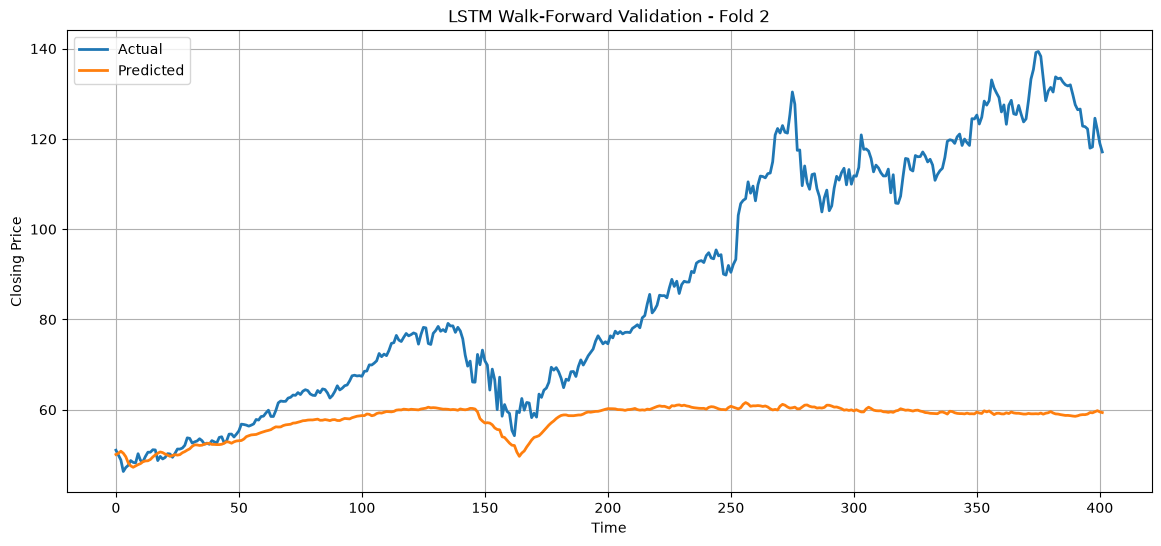

In [53]:
#plotting the actual and predicted fold 2

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(lstm_fold2_actual, label="Actual", linewidth = 2)
plt.plot(lstm_fold2_pred, label="Predicted", linewidth = 2)

plt.title("LSTM Walk-Forward Validation - Fold 2")
plt.xlabel("Time")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True)

plt.show()

In [54]:
import pandas as pd
import numpy as np

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "MLP",
        "Raw LSTM"
    ],

    "Random RMSE": [
        rmse_lr_random,
        rmse_dt_random,
        rmse_rf_random,
        rmse_xgb_random,
        rmse_mlp_random,
        np.nan
    ],

    "Time RMSE": [
        rmse_lr_time,
        rmse_dt_time,
        rmse_rf_time,
        rmse_xgb_time,
        rmse_mlp_time,
        rmse_lstm_time
    ],

    "Walk Mean RMSE": [
        mean_rmse_lr_wf,
        mean_rmse_dt_wf,
        mean_rmse_rf_wf,
        mean_rmse_xgb_wf,
        mean_rmse_mlp_wf,
        mean_rmse_lstm_raw_wf
    ],

    "Walk Median RMSE": [
        np.median(lr_fold_rmse),
        np.median(dt_fold_rmse),
        np.median(rf_fold_rmse),
        np.median(xgb_fold_rmse),
        np.median(mlp_fold_rmse),
        np.median(lstm_raw_fold_rmse)
    ],

    "Walk Forward rmse Std": [
        np.std(lr_fold_rmse),
        np.std(dt_fold_rmse),
        np.std(rf_fold_rmse),
        np.std(xgb_fold_rmse),
        np.std(mlp_fold_rmse),
        np.std(lstm_raw_fold_rmse)
    ]
})


# Best RMSE across the available validation methods
results["Best RMSE"] = results[
    [
        "Random RMSE",
        "Time RMSE",
        "Walk Mean RMSE"
    ]
].min(axis=1)


# Absolute increase in RMSE from random to walk-forward
results["RMSE Increase (Walk − Random)"] = (
    results["Walk Mean RMSE"]
    - results["Random RMSE"]
)


# Percentage increase relative to random validation
results["Validation Inflation (%)"] = (
    (
        results["Walk Mean RMSE"]
        - results["Random RMSE"]
    )
    / results["Random RMSE"]
) * 100


# How many times larger walk-forward RMSE is than random RMSE
results["Overestimation Ratio (Walk/Random)"] = (
    results["Walk Mean RMSE"]
    / results["Random RMSE"]
)


# Put columns in the exact order you want
results = results[
    [
        "Model",
        "Random RMSE",
        "Time RMSE",
        "Walk Mean RMSE",
        "Best RMSE",
        "Walk Median RMSE",
        "Walk Forward rmse Std",
        "RMSE Increase (Walk − Random)",
        "Validation Inflation (%)",
        "Overestimation Ratio (Walk/Random)"
    ]
]


# Round for cleaner display
results = results.round(2)

results

,Model,Random RMSE,Time RMSE,Walk Mean RMSE,Best RMSE,Walk Median RMSE,Walk Forward rmse Std,RMSE Increase (Walk − Random),Validation Inflation (%),Overestimation Ratio (Walk/Random)
0,Linear Regression,4.45,7.33,18.03,4.45,7.84,19.47,13.58,305.25,4.05
1,Decision Tree,3.38,35.86,23.67,3.38,20.55,15.14,20.29,600.24,7.00
2,Random Forest,2.71,37.10,24.01,2.71,20.54,15.55,21.30,784.87,8.85
3,XGBoost,2.92,40.55,26.21,2.92,21.60,16.38,23.29,797.76,8.98
4,MLP,2.79,4.98,9.94,2.79,6.32,6.17,7.14,255.57,3.56
5,Raw LSTM,NaN,18.51,14.44,14.44,8.44,13.26,NaN,NaN,NaN


###### Random splitting produced substantially lower RMSE than walk-forward validation for all five directly comparable models, with walk-forward error ranging from approximately 3.56× to 8.98× the random-split error.
###### The magnitude of validation inflation was model-dependent. Tree-based models showed the largest deterioration, with Decision Tree, Random Forest, and XGBoost exhibiting approximately 600%, 785%, and 798% increases in RMSE, respectively.
###### Validation strategy also changed conclusions about relative model performance. Random Forest achieved the lowest RMSE under random splitting (2.71), whereas MLP achieved the lowest mean walk-forward RMSE (9.94) among models evaluated under all three strategies.
###### Walk-forward variability was substantial for several models. In particular, Linear Regression had a mean walk-forward RMSE of 18.03 but a median of only 7.84, together with an SD of 19.47, indicating that its average performance was strongly influenced by difficult temporal fold(s).

### **Figure 1: Comparison of RMSE Across Validation Strategies** 

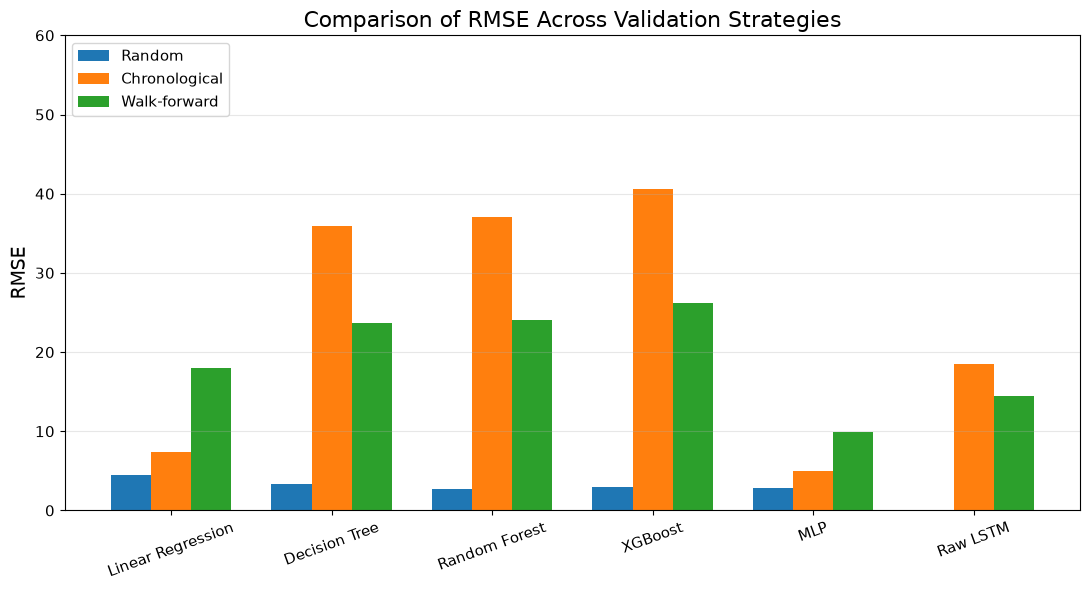

In [55]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(results))
width = 0.25

plt.figure(figsize=(11, 6))

plt.bar(
    x - width,
    results["Random RMSE"],
    width,
    label="Random"
)

plt.bar(
    x,
    results["Time RMSE"],
    width,
    label="Chronological"
)

plt.bar(
    x + width,
    results["Walk Mean RMSE"],
    width,
    label="Walk-forward"
)

plt.xticks(
    x,
    results["Model"],
    rotation=20,
    fontsize=11
)

plt.yticks(fontsize=11)

plt.ylabel(
    "RMSE",
    fontsize=14
)

plt.title(
    "Comparison of RMSE Across Validation Strategies",
    fontsize=16
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.ylim(0, 60)

plt.legend(
    fontsize=11
)

plt.tight_layout()

plt.show()

### **Figure 2: Increase in RMSE from Random to Walk-Forward Validation** 

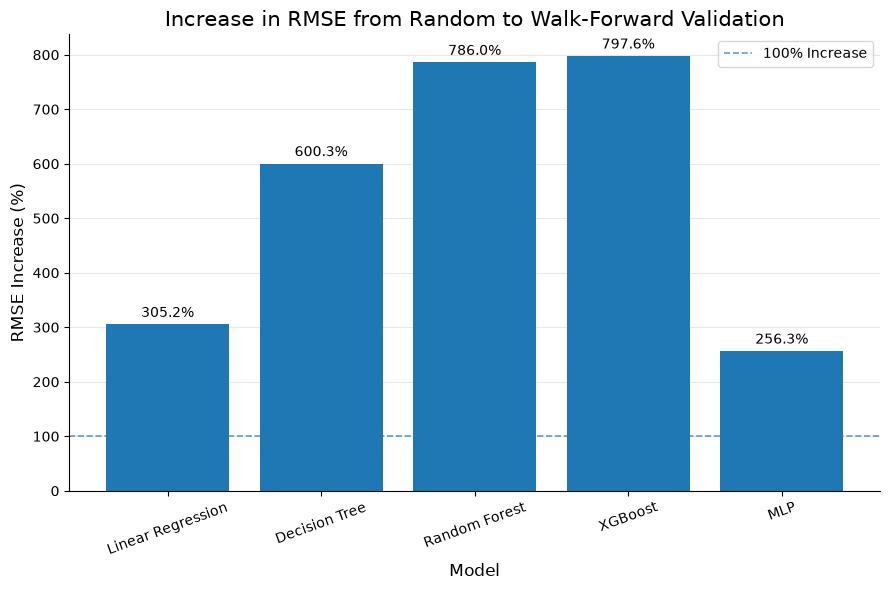

In [56]:
import matplotlib.pyplot as plt

# Calculate percentage increase from random to walk-forward validation
results["Validation Inflation (%)"] = (
    (
        results["Walk Mean RMSE"]
        - results["Random RMSE"]
    )
    / results["Random RMSE"]
) * 100

# Exclude models without a random-split result, such as Raw LSTM
plot_data = results.dropna(
    subset=["Validation Inflation (%)"]
).copy()

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.bar(
    plot_data["Model"],
    plot_data["Validation Inflation (%)"]
)

ax.set_title(
    "Increase in RMSE from Random to Walk-Forward Validation",
    fontsize=15
)

ax.set_xlabel(
    "Model",
    fontsize=12
)

ax.set_ylabel(
    "RMSE Increase (%)",
    fontsize=12
)

ax.grid(
    axis="y",
    alpha=0.3
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="x",
    labelrotation=20,
    labelsize=10
)

ax.tick_params(
    axis="y",
    labelsize=10
)

ax.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in plot_data["Validation Inflation (%)"]
    ],
    padding=3,
    fontsize=10
)

ax.axhline(
    y=100,
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    label="100% Increase"
)

ax.legend()

plt.tight_layout()
plt.show()

In [57]:
walk_df = pd.DataFrame({
    "Fold": [1,2,3,4,5],
    "Linear": lr_fold_rmse,
    "Decision Tree": dt_fold_rmse,
    "Random Forest": rf_fold_rmse,
    "XGBoost": xgb_fold_rmse,
    "MLP": mlp_fold_rmse,
    "Raw LSTM": lstm_raw_fold_rmse
})

walk_df

,Fold,Linear,Decision Tree,Random Forest,XGBoost,MLP,Raw LSTM
0,1,14.642109,6.296055,6.020312,6.113356,19.484635,2.167240
1,2,56.384374,43.049166,43.440731,44.556234,14.732650,38.221886
2,3,6.461666,20.547307,20.537747,21.604878,6.228070,19.158601
3,4,4.825427,9.102224,9.331624,12.665003,2.917196,4.201691
4,5,7.844986,39.372230,40.743982,46.113929,6.319886,8.437215


### **Figure 3: Walk-forward Performance Across Folds** 

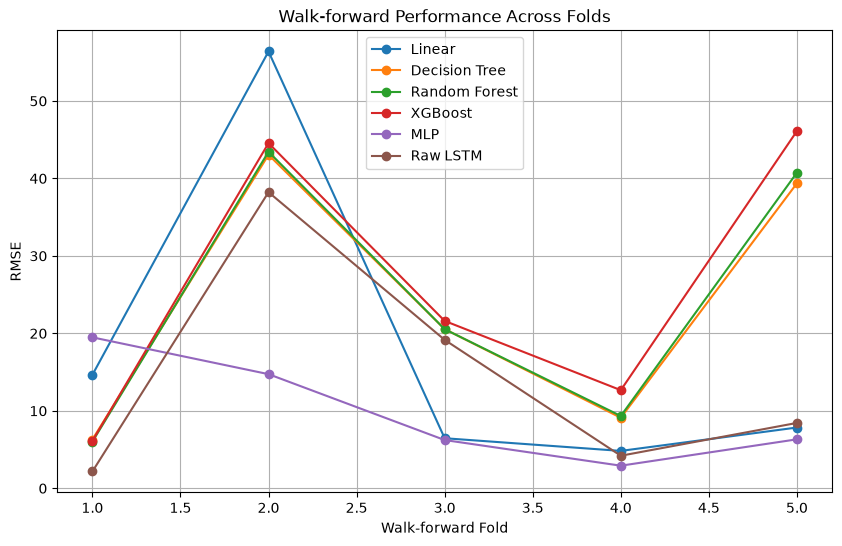

In [58]:
plt.figure(figsize=(10,6))

for col in walk_df.columns[1:]:
    plt.plot(
        walk_df["Fold"],
        walk_df[col],
        marker="o",
        label=col
    )

plt.xlabel("Walk-forward Fold")
plt.ylabel("RMSE")
plt.title("Walk-forward Performance Across Folds")
plt.legend()
plt.grid(True)
plt.show()

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Build Apple walk-forward results directly from existing variables
netflix_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "MLP",
        "Raw LSTM"
    ],

    "Walk-Forward Mean RMSE": [
        np.mean(lr_fold_rmse),
        np.mean(dt_fold_rmse),
        np.mean(rf_fold_rmse),
        np.mean(xgb_fold_rmse),
        np.mean(mlp_fold_rmse),
        np.mean(lstm_raw_fold_rmse)
    ],

    "Walk-Forward RMSE Std": [
        np.std(lr_fold_rmse),
        np.std(dt_fold_rmse),
        np.std(rf_fold_rmse),
        np.std(xgb_fold_rmse),
        np.std(mlp_fold_rmse),
        np.std(lstm_raw_fold_rmse)
    ]
})

print(netflix_results)

               Model  Walk-Forward Mean RMSE  Walk-Forward RMSE Std
0  Linear Regression               18.031712              19.465135
1      Decision Tree               23.673396              15.138939
2      Random Forest               24.014879              15.548116
3            XGBoost               26.210680              16.378644
4                MLP                9.936487               6.168840
5           Raw LSTM               14.437326              13.261375


### **Figure 4: Walk-Forward RMSE and Fold-to-Fold Variability Across Models** 

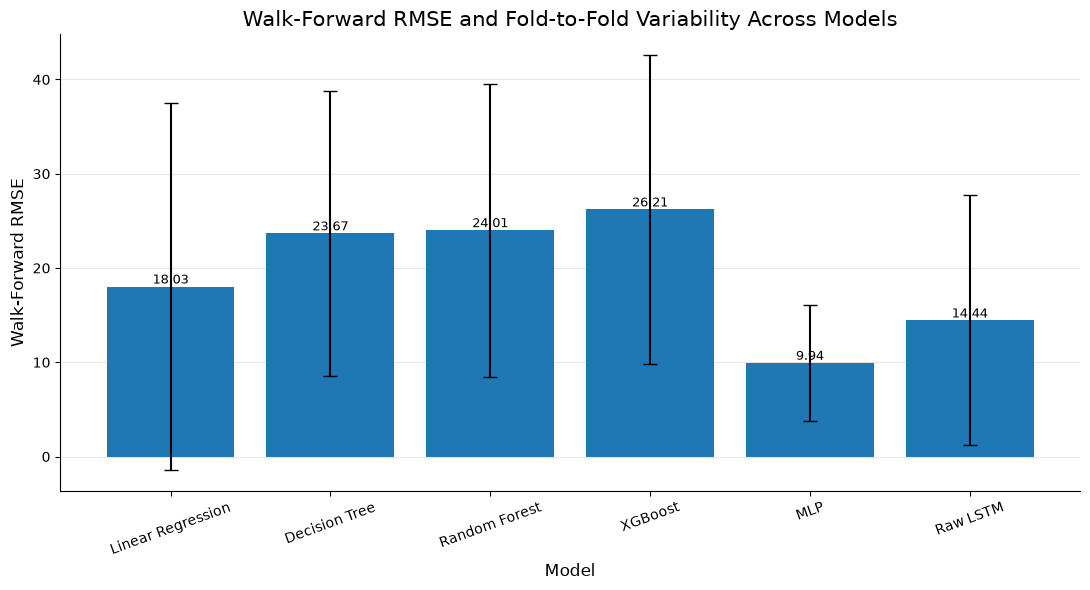

In [60]:
fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    netflix_results["Model"],
    netflix_results["Walk-Forward Mean RMSE"],
    yerr=netflix_results["Walk-Forward RMSE Std"],
    capsize=5
)

ax.set_xlabel("Model", fontsize=12)
ax.set_ylabel("Walk-Forward RMSE", fontsize=12)

ax.set_title(
    "Walk-Forward RMSE and Fold-to-Fold Variability Across Models",
    fontsize=15
)

ax.tick_params(
    axis="x",
    rotation=20
)

ax.grid(
    axis="y",
    alpha=0.3
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Add mean RMSE above each bar
for bar, value in zip(
    bars,
    netflix_results["Walk-Forward Mean RMSE"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

### **Figure 5: Model Predictions During a High-Shift Walk-Forward Test Period (Fold 2)** 

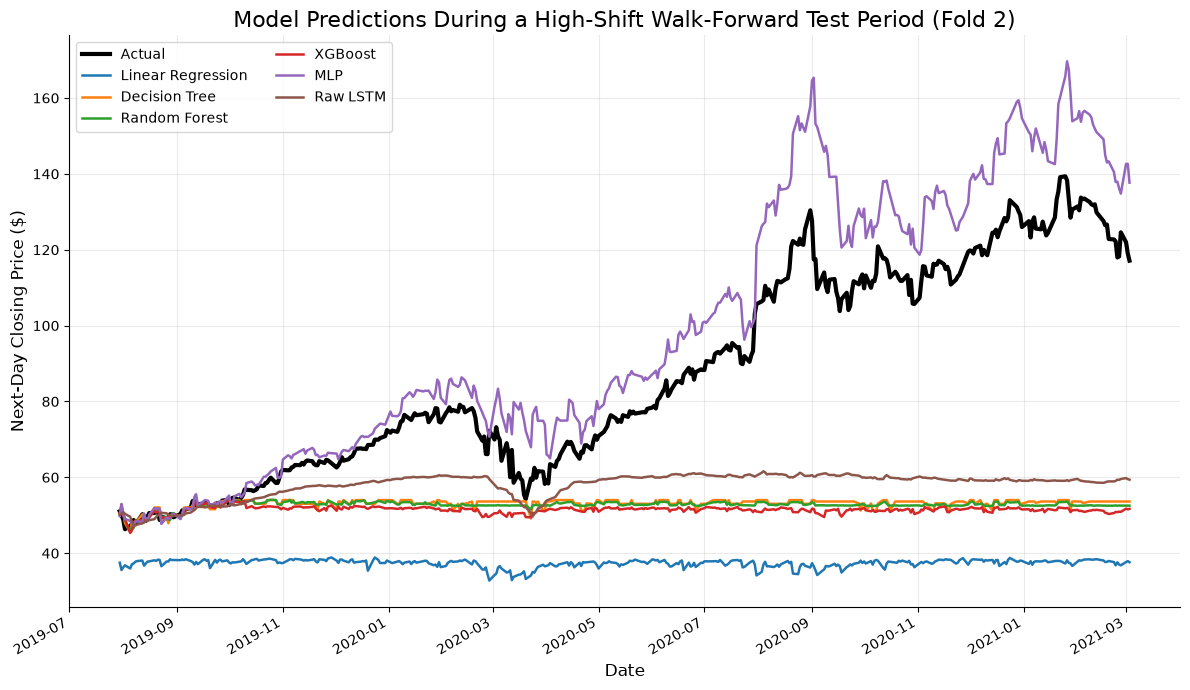

In [61]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))

# Actual stock price
ax.plot(
    lr_fold2_dates,
    lr_fold2_actual,
    label="Actual",
    linewidth=3,
    color="black"
)

# Linear Regression
ax.plot(
    lr_fold2_dates,
    lr_fold2_pred,
    label="Linear Regression",
    linewidth=1.8
)

# Decision Tree
ax.plot(
    dt_fold2_dates,
    dt_fold2_pred,
    label="Decision Tree",
    linewidth=1.8
)

# Random Forest
ax.plot(
    rf_fold2_dates,
    rf_fold2_pred,
    label="Random Forest",
    linewidth=1.8
)

# XGBoost
ax.plot(
    xgb_fold2_dates,
    xgb_fold2_pred,
    label="XGBoost",
    linewidth=1.8
)

# MLP
ax.plot(
    mlp_fold2_dates,
    mlp_fold2_pred,
    label="MLP",
    linewidth=1.8
)

# Raw LSTM
ax.plot(
    lstm_fold2_dates,
    lstm_fold2_pred,
    label="Raw LSTM",
    linewidth=1.8
)

ax.set_title(
    "Model Predictions During a High-Shift Walk-Forward Test Period (Fold 2)",
    fontsize=16
)

ax.set_xlabel(
    "Date",
    fontsize=12
)

ax.set_ylabel(
    "Next-Day Closing Price ($)",
    fontsize=12
)

ax.grid(
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    fontsize=10,
    ncol=2
)

fig.autofmt_xdate()

plt.tight_layout()
plt.show()

###### Fold 2 illustrates a difficult future period in which Apple prices increased substantially relative to earlier observations. Model responses differed considerably. Linear Regression substantially underpredicted the future price level, while Decision Tree, Random Forest, and XGBoost predictions also remained concentrated near lower price levels. The raw LSTM adjusted upward only partially. MLP responded more strongly to the changing price level but frequently overshot the observed values. These results demonstrate that performance under temporal distribution shift is model- and period-dependent, and that no single model response observed on Netflix generalized uniformly to Apple.

In [62]:
ranking_results = results[
    results["Random RMSE"].notna()
].copy()

ranking_results["Random Rank"] = (
    ranking_results["Random RMSE"]
    .rank(method="min", ascending=True)
    .astype(int)
)

ranking_results["Walk Rank"] = (
    ranking_results["Walk Mean RMSE"]
    .rank(method="min", ascending=True)
    .astype(int)
)

ranking_results[
    [
        "Model",
        "Random RMSE",
        "Random Rank",
        "Walk Mean RMSE",
        "Walk Rank"
    ]
]

,Model,Random RMSE,Random Rank,Walk Mean RMSE,Walk Rank
0,Linear Regression,4.45,5,18.03,2
1,Decision Tree,3.38,4,23.67,3
2,Random Forest,2.71,1,24.01,4
3,XGBoost,2.92,3,26.21,5
4,MLP,2.79,2,9.94,1


In [63]:
from scipy.stats import spearmanr

rho, p_value = spearmanr(
    ranking_results["Random Rank"],
    ranking_results["Walk Rank"]
)

print("Spearman rank correlation:", rho)
print("p-value:", p_value)

Spearman rank correlation: -0.19999999999999998
p-value: 0.7470600781046621


In [64]:
apple_results = results.copy()
apple_results.to_csv(
    "../outputs/apple_results.csv",
    index=False
)

In [65]:
import pandas as pd
import numpy as np

fold_results = {
    "Linear Regression": lr_fold_rmse,
    "Decision Tree": dt_fold_rmse,
    "Random Forest": rf_fold_rmse,
    "XGBoost": xgb_fold_rmse,
    "MLP": mlp_fold_rmse,
    "Raw LSTM": lstm_raw_fold_rmse
}

period_analysis = []

for model, scores in fold_results.items():

    scores = np.array(scores)

    worst_fold = np.argmax(scores) + 1
    worst_rmse = np.max(scores)

    mean_all = np.mean(scores)

    scores_without_worst = np.delete(
        scores,
        np.argmax(scores)
    )

    mean_without_worst = np.mean(
        scores_without_worst
    )

    worst_contribution = (
        worst_rmse / np.sum(scores)
    ) * 100

    period_analysis.append({
        "Model": model,
        "Worst Fold": worst_fold,
        "Worst Fold RMSE": worst_rmse,
        "Mean RMSE": mean_all,
        "Mean Without Worst Fold": mean_without_worst,
        "Worst Fold Contribution (%)": worst_contribution
    })

period_analysis = pd.DataFrame(period_analysis)

period_analysis.round(2)

,Model,Worst Fold,Worst Fold RMSE,Mean RMSE,Mean Without Worst Fold,Worst Fold Contribution (%)
0,Linear Regression,2,56.38,18.03,8.44,62.54
1,Decision Tree,2,43.05,23.67,18.83,36.37
2,Random Forest,2,43.44,24.01,19.16,36.18
3,XGBoost,5,46.11,26.21,21.23,35.19
4,MLP,1,19.48,9.94,7.55,39.22
5,Raw LSTM,2,38.22,14.44,8.49,52.95


###### Walk-forward evaluation revealed that forecasting errors were often concentrated in specific temporal periods rather than distributed uniformly across folds. On Netflix, Fold 2 was the worst-performing fold for five of the six evaluated models and accounted for more than half of the total fold-level RMSE for Random Forest, XGBoost, and the raw LSTM. Apple showed a less uniform pattern: Fold 2 was the worst period for Linear Regression, Decision Tree, Random Forest, and the raw LSTM, whereas XGBoost and MLP experienced their largest errors in Folds 5 and 1, respectively. Apple Linear Regression was particularly sensitive, with its mean RMSE decreasing from 18.03 to 8.44 when its worst fold was excluded. These findings indicate that aggregate walk-forward performance can be strongly influenced by specific future periods and that temporal robustness varies across both models and datasets.

In [66]:
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

shift_rows = []

for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):

    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    train_min = y_train_fold.min()
    train_max = y_train_fold.max()

    test_min = y_test_fold.min()
    test_max = y_test_fold.max()

    # Test observations above anything seen during training
    above_train_max = (y_test_fold > train_max)

    # Test observations below anything seen during training
    below_train_min = (y_test_fold < train_min)

    outside_range = above_train_max | below_train_min

    shift_rows.append({
        "Fold": fold,

        "Train Min": train_min,
        "Train Max": train_max,

        "Test Min": test_min,
        "Test Max": test_max,

        "Test Above Train Max (%)":
            above_train_max.mean() * 100,

        "Test Below Train Min (%)":
            below_train_min.mean() * 100,

        "Test Outside Train Range (%)":
            outside_range.mean() * 100,

        "Upper Range Extension":
            max(0, test_max - train_max),

        "Lower Range Extension":
            max(0, train_min - test_min)
    })

shift_analysis = pd.DataFrame(shift_rows)

shift_analysis.round(2)

,Fold,Train Min,Train Max,Test Min,Test Max,Test Above Train Max (%),Test Below Train Min (%),Test Outside Train Range (%),Upper Range Extension,Lower Range Extension
0,1,20.99,41.32,33.80,54.97,70.15,0.0,70.15,13.66,0
1,2,20.99,54.97,46.33,139.36,87.31,0.0,87.31,84.39,0
2,3,20.99,139.36,113.44,178.27,71.39,0.0,71.39,38.91,0
3,4,20.99,178.27,123.16,196.26,33.58,0.0,33.58,17.99,0
4,5,20.99,196.26,171.83,286.19,92.79,0.0,92.79,89.93,0


In [67]:
shift_analysis["LR RMSE"] = lr_fold_rmse
shift_analysis["DT RMSE"] = dt_fold_rmse
shift_analysis["RF RMSE"] = rf_fold_rmse
shift_analysis["XGB RMSE"] = xgb_fold_rmse
shift_analysis["MLP RMSE"] = mlp_fold_rmse
shift_analysis["LSTM RMSE"] = lstm_raw_fold_rmse

shift_analysis.round(2)

,Fold,Train Min,Train Max,Test Min,Test Max,Test Above Train Max (%),Test Below Train Min (%),Test Outside Train Range (%),Upper Range Extension,Lower Range Extension,LR RMSE,DT RMSE,RF RMSE,XGB RMSE,MLP RMSE,LSTM RMSE
0,1,20.99,41.32,33.80,54.97,70.15,0.0,70.15,13.66,0,14.64,6.30,6.02,6.11,19.48,2.17
1,2,20.99,54.97,46.33,139.36,87.31,0.0,87.31,84.39,0,56.38,43.05,43.44,44.56,14.73,38.22
2,3,20.99,139.36,113.44,178.27,71.39,0.0,71.39,38.91,0,6.46,20.55,20.54,21.60,6.23,19.16
3,4,20.99,178.27,123.16,196.26,33.58,0.0,33.58,17.99,0,4.83,9.10,9.33,12.67,2.92,4.20
4,5,20.99,196.26,171.83,286.19,92.79,0.0,92.79,89.93,0,7.84,39.37,40.74,46.11,6.32,8.44


###### Target-range analysis showed that difficult walk-forward periods frequently coincided with future prices extending beyond the range represented in the expanding training history. However, the relationship was strongly model-dependent. On Netflix, Fold 2 placed 94.03% of test targets outside the historical training range and produced severe errors for Decision Tree, Random Forest, XGBoost, MLP, and the raw LSTM, while Linear Regression remained comparatively accurate. On Apple, Fold 2 similarly produced large errors across several models, including Linear Regression. Apple Fold 5 provides an important contrast: despite 92.79% of test targets exceeding the previous training maximum, Linear Regression, MLP, and LSTM maintained substantially lower errors than the tree-based models. These results indicate that target-range extrapolation characterizes several difficult forecasting periods but does not independently determine forecasting error; model response to these shifts varies across architectures, datasets, and temporal periods.